In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]='0'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]='0.25'
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]='false'
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]='platform'
import jax
import numpy as np
import torch
from jax import numpy as jnp
from utils import create_mnist_classification_dataset, create_cifar_gs_classification_dataset, scaled_shifted_sigmoid, threshold, scaled_shifted_tanh, plot_dynamics
# from model import BatchRNN
from trainer import validate, run_epoch, create_train_state
from types import SimpleNamespace
from flax.training import train_state, checkpoints
import optax
import os
from utils import map_nested_fn
from model import apply_model, update_model, eval_model
from flax import linen as nn
from typing import Sequence
from jaxlib import xla_extension as xlx
import seaborn as sns
import matplotlib.pyplot as plt


# set printoptions
jnp.set_printoptions(precision=3, suppress=True)

In [2]:
class minGRULayer(nn.Module):
    '''
    MGU Layer
    We use a modified version of the h_tilde calculation in the MGU cell for better performance.
    - $f_t = \sigma(W^{fx} x_t + U^{fh} h_{t-1} + b^f)$
    - $\~{h}_t = \tanh(W^{hx} x_t + f_t \odot (U^{hh} h_{t-1} + b^h))$
    
    Args:
        hidden_size: int, size of hidden state
        output_size: int, size of output
    '''
    hidden_size: int
    output_size: int

    @nn.compact
    def __call__(self, x):

        def update(self, state, x):
            h = state[0]
            z_htilde = nn.Dense(2*self.hidden_size, name='Dense_x')(x)
            z_preact, h_tilde = jnp.split(z_htilde, 2, axis=-1)
            z = nn.sigmoid(z_preact)
            h_new = (1 - z) * h + z * h_tilde
            return (h_new,), (h_new, z, z_preact)

        scan_update = nn.scan(
            update,
            variable_broadcast='params',
            split_rngs={'params': False},
            in_axes=0,
            out_axes=0,
        )
        h = jnp.zeros((self.hidden_size,))
        state = (h,)
        _, state_hist = scan_update(self, state, x)

        return state_hist


class HeinsenMinGRULayer(nn.Module):
    '''
    MGU Layer
    We use a modified version of the h_tilde calculation in the MGU cell for better performance.
    - $f_t = \sigma(W^{fx} x_t + U^{fh} h_{t-1} + b^f)$
    - $\~{h}_t = \tanh(W^{hx} x_t + f_t \odot (U^{hh} h_{t-1} + b^h))$
    
    Args:
        hidden_size: int, size of hidden state
        output_size: int, size of output
    '''
    hidden_size: int
    output_size: int
    decay: bool
    timedecay_mean: Sequence[float]
    key: jax.random.key
    hidden_nonlinearity: xlx.PjitFunction


    @nn.compact
    def __call__(self, x):


        def softplus(x):
            return jnp.log(1 + jnp.exp(x))
        def safe_softplus(x):
            x_safe = jnp.where(x > 10, 0, x)
            return jnp.where(x > 10, x, softplus(x_safe))
        def log_g(x):
            x_safe = jnp.where(x == -0.5, x+1e-5, x)
            return jnp.where(x >= 0, jnp.log(x_safe+0.5), -safe_softplus(-x))        
        
        def exponential_decay_kernel(time_constants, length):
            """
            Generate an exponential decay kernel for each time constant.
            Args:
                time_constants: Array of time constants (shape: [hidden_size]).
                length: Length of the kernel.
            Returns:
                A kernel matrix of shape [hidden_size, length].
            """
            t = jnp.arange(length)
            kernel = jnp.exp(-t[:, None] / time_constants[None, :])
            return kernel.T  # Shape: [hidden_size, length]


        def heinsen_update(z, h):
            '''
            we can formulate h_{t} = (1 - z_t) * h_{t-1} + z_t * h_tilde_t as 
            h_t = a_t * h_{t-1} + b_t with a_t = 1 - z_t and b_t = z_t * h_tilde_t which can be precomputed
            '''
            x_0 = -10000.
            log_a = -safe_softplus(z)
            log_b = -safe_softplus(-z) + log_g(h)
            a_star = jnp.cumsum(log_a)

            c = log_b - a_star 
            c = jnp.pad(c, (1, 0), constant_values=x_0)
            d = jax.lax.cumlogsumexp(c)
            d = d[1:] # tailing d
            log_final = a_star + d
            return jnp.exp(log_final)
        
        vj_heinsen_update = jax.vmap(jax.jit(heinsen_update), in_axes=(1, 1), out_axes=1)

        # Define trainable time constants
        lower_bound = 1.0
        upper_bound = 1.5*self.timedecay_mean[0]

        
        # time_constants = self.param(
        #     'time_constants',
        #     lambda rng, shape: jax.random.uniform(self.key, (self.hidden_size,), minval=self.timedecay_mean[1], maxval=self.timedecay_mean[0]),
        #     (self.hidden_size,)
        # )

        time_constants = jax.random.uniform(self.key, (self.hidden_size,), minval=self.timedecay_mean[1], maxval=self.timedecay_mean[0])
        # time_constants = bimodal_gaussian(key, (self.hidden_size,), self.timedecay_mean[0], self.timedecay_mean[1], 2/3*self.timedecay_mean[0], 2/3*self.timedecay_mean[1], weight1=0.5)

        # Ensure time constants are positive
        time_constants=jnp.abs(time_constants)
        # time_constants = jax.nn.softplus(time_constants)
        # time_constants = jnp.clip(time_constants, lower_bound, upper_bound)

        # Generate decay kernels
        decay_kernels = exponential_decay_kernel(time_constants, 50)

        def update(x):
            '''
            As the x is not scanned anymore, x is 2D array (n_ts, n_features)
            - for sMNIST, the first layer will have x of shape (784, 1)

            '''
            z_htilde = nn.Dense(2*self.hidden_size, name='Dense_x')(x) # z_htilde: (784, 128)
            z_preact, h_tilde_preact = jnp.split(z_htilde, 2, axis=-1) # z_preact and h_tilde_preact: (784, 64)
            
            # Convolve z_preact with decay kernels
            if self.decay:
                z_preact = jax.vmap(
                    lambda z_, k: jax.scipy.signal.convolve(z_, k, mode='same'),
                    in_axes=(1, 0), out_axes=1
                )(z_preact, decay_kernels)

            h_preact = vj_heinsen_update(z_preact, h_tilde_preact) # h_new: (784, 64)
            if self.hidden_nonlinearity is not None:
                # print(self.hidden_nonlinearity, " being applied!")
                h_new = self.hidden_nonlinearity(h_preact)
            return (h_new, z_preact, h_tilde_preact, h_preact)
        
        state_hist = update(x)
        return state_hist

class RNNBackbone(nn.Module):
    hidden_size: int
    output_size: int
    n_layers: int
    decay: Sequence[bool]
    timedecay_mean: Sequence[float]
    seed: int
    hidden_nonlinearity: xlx.PjitFunction
    recurrent_layer: nn.Module = HeinsenMinGRULayer

    @nn.compact
    def __call__(self, x):
        key = jax.random.PRNGKey(self.seed)
        key_list = [key]*self.n_layers
        key_list = jax.random.split(key,self.n_layers)
        state_hist = []
        
        for i in range(self.n_layers-1):
            # print("Layer: ", i, "Decay: ", self.decay[i])
            x = self.recurrent_layer(self.hidden_size, self.output_size, self.decay[i], self.timedecay_mean, key_list[i], self.hidden_nonlinearity)(x)
            state_hist.append(x)
            x = x[0]
        # print("Layer: ", self.n_layers-1, "Decay: ", self.decay[self.n_layers-1])
        x = self.recurrent_layer(self.hidden_size, self.output_size, self.decay[self.n_layers-1], self.timedecay_mean, key_list[i], self.hidden_nonlinearity)(x)
        state_hist.append(x)
        out = nn.Dense(self.output_size, name='Dense_Out')(x[0])
        return state_hist, out
    
BatchRNN = nn.vmap(RNNBackbone, in_axes=0, out_axes=0, variable_axes={'params': None}, split_rngs={'params': False})


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_431858/61955119.py:2: SyntaxWarning: invalid escape sequence '\s'
  '''
/tmp/ipykernel_431858/61955119.py:41: SyntaxWarning: invalid escape sequence '\s'
  '''


In [3]:
def round_weights_to_nearest(weights, step=0.5):
    """
    Round weights to the nearest multiple of a given step.

    Args:
        weights: The weights to be rounded (e.g., a JAX PyTree or array).
        step: The step size to round to (default is 0.1).

    Returns:
        Rounded weights.
    """
    return jax.tree_map(lambda w: jnp.round(w / step) * step, weights)


In [4]:
def train(key, state, trainloader, val_loader, testloader, n_epochs, reg_factor, result_dir, cktp_dir, round=False):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    # 'batch_loss' = [loss_sample1, loss_sample2, ..., loss_sampleBS]
    # 'loss' = [loss_batch1, loss_batch2, ..., loss_batchN] where N is the number of batches and loss_batchX = mean([loss_sample1, loss_sample2, ..., loss_sampleBS])
    keys_to_track = ['grads', 'loss', 'state'] #['grads', 'loss', 'state', 'batch_x', 'batch_y'] # ['batch_x', 'batch_y', 'state', 'grads']
    inner_keys_to_track = [] #['batch_loss', 'net_dyn']
    aux_dict_training = []

    best_val_acc = 0.0
    improvement = 0.01 # 1%, minimum improvement to save checkpoint

    async_manager = checkpoints.AsyncManager()

    for epoch in range(n_epochs):
        key, subkey = jax.random.split(key) # not used in run_epoch (TODO: remove?)
        state, train_loss, train_accuracy, (break_flag, aux_dict_epoch) = run_epoch(state, trainloader, key, reg_factor=reg_factor, lim_batch=None, keys_to_track=keys_to_track, inner_keys_to_track=inner_keys_to_track)
        aux_dict_training.append(aux_dict_epoch)
        
        if round:
            state = state.replace(params=round_weights_to_nearest(state.params, step=0.5))

        
        if break_flag:
            break
        val_loss, val_acc  = validate(state, val_loader)
        if val_acc > best_val_acc + improvement:
            best_val_acc = val_acc
            if best_val_acc > 0.97: improvement = 0.001 # 0.1%
            checkpoints.save_checkpoint(ckpt_dir=cktp_dir, target=state, step=state.step, overwrite=True, async_manager=async_manager)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_accuracy*100:.2f}% | val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}%")


    test_loss, test_acc  = validate(state, testloader)
    print(f"Final Test | test_loss: {test_loss:.4f} | test_acc: {test_acc*100:.2f}%")

    final_state = state
    # Save training dynamics
    np.savez(os.path.join(result_dir, 'training_dynamics.npz'), 
            train_losses=train_losses, 
            train_accuracies=train_accuracies, 
            val_losses=val_losses, 
            val_accuracies=val_accuracies)
    np.savez(os.path.join(result_dir, 'test_loss.npz'),
             test_loss=test_loss, test_acc=test_acc)
    
    return train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc, aux_dict_training, final_state

In [5]:
args_dict = {
    "id_note": "testing",
    "model_code": "nolayer_dyn",
    "sweep_steepness": False,
    "time_decay_mean": (10.0, 1.0),
    "decay": "11",
    "dataset": "mnist",
    "dataset_version": "sequential",
    "hidden_dim": 50,
    "batch_size": 128,
    "n_layers": 4,
    "n_epochs": 10,
    "lr": 1e-3,
    "reg_factor": 0.0,
    "hidden_activation": 'threshold',
    "hidden_nonlinearity": None,
    "seed": 0,
    "gpu_index": "1",
    "gpu_mem_fraction": "0.95",
    "sigmoid_scale": 10.0,
    "sigmoid_center": 0.5,
    "rounding": True
}

args = SimpleNamespace(**args_dict)




In [6]:
for c in args.decay:
    if c not in ['0', '1']:
        raise ValueError("Decay must be a list of 0s and 1s.")
args.decay = [bool(int(c)) for c in args.decay]

if args.model_code == 'firstlayer_dyn':
    args.decay = [False]*args.n_layers
    args.decay[0] = True
    args.reg_factor = 0.0
elif args.model_code == 'nolayer_dyn':
    args.decay = [False]*args.n_layers
    args.reg_factor = 0.0
elif args.model_code == 'alllayer_dyn':
    args.decay = [True]*args.n_layers

print(args.decay)

[False, False, False, False]


In [7]:
# Print arguments
print("Parsed arguments:")
print(f"Time Decay Mean: {args.time_decay_mean}")
print(f"Model Code: {args.model_code}")
print(f"Decay: {args.decay}")
print(f"Dataset: {args.dataset}")
print(f"Dataset Version: {args.dataset_version}")
print(f"Hidden Dimension: {args.hidden_dim}")
print(f"Batch Size: {args.batch_size}")
print(f"Number of Layers: {args.n_layers}")
print(f"Number of Epochs: {args.n_epochs}")
print(f"Learning Rate: {args.lr}")
print(f"Regularization Factor: {args.reg_factor}")
print(f"Hidden Activation: {args.hidden_activation}")
print(f"Seed: {args.seed}")

if args.hidden_activation is not None:
    if args.hidden_activation == "sigmoid":
        args.hidden_nonlinearity = jax.nn.sigmoid
    elif args.hidden_activation == "scaled_sigmoid":
        print("Scale of scaled sigmoid:", args.sigmoid_scale)
        args.hidden_nonlinearity = lambda x: scaled_shifted_sigmoid(x, scale=args.sigmoid_scale, center=args.sigmoid_center)
    elif args.hidden_activation == "scaled_tanh":
        args.hidden_nonlinearity = lambda x: scaled_shifted_tanh(x, scale=args.sigmoid_scale, center=args.sigmoid_center)
    elif args.hidden_activation == "relu":
        args.hidden_nonlinearity = jax.nn.relu
    elif args.hidden_activation == "tanh":
        args.hidden_nonlinearity = jax.nn.tanh
    elif args.hidden_activation == "selu":
        args.hidden_nonlinearity = jax.nn.selu
    elif args.hidden_activation == "threshold":
        print("Using threshold")
        args.hidden_nonlinearity = lambda x: threshold(x, thr=args.sigmoid_center)
    else:
        print("Invalid hidden nonlinearity. Using default (None).")
        args.hidden_nonlinearity = None
else:
    print("Using default hidden nonlinearity (None).")

Parsed arguments:
Time Decay Mean: (10.0, 1.0)
Model Code: nolayer_dyn
Decay: [False, False, False, False]
Dataset: mnist
Dataset Version: sequential
Hidden Dimension: 50
Batch Size: 128
Number of Layers: 4
Number of Epochs: 10
Learning Rate: 0.001
Regularization Factor: 0.0
Hidden Activation: threshold
Seed: 0
Using threshold


In [8]:
# fix random seed
key = jax.random.PRNGKey(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)


# set hyperparameters
TIMEDECAY_MEAN = args.time_decay_mean
DECAY = args.decay

DATASET_VERSION = args.dataset_version
HIDDEN_DIM = args.hidden_dim #2*x*(1+x*(n-1)+n+5+10/64)
BATCH_SIZE = args.batch_size
N_LAYERS = args.n_layers
N_EPOCHS = args.n_epochs
LR = args.lr
REG_FACTOR = args.reg_factor # 1e-8, 1e-6, 1e-7, 1e-9, 0.0



In [ ]:
# get dataset
if args.dataset=="cifar10":
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_cifar_gs_classification_dataset(bsz=BATCH_SIZE)
else:
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_mnist_classification_dataset(bsz=BATCH_SIZE, root="/home/christian/LearningJAX/data/MNIST",  version=DATASET_VERSION)


batch_x, batch_y = next(iter(testloader))
print("Batch size:", batch_x.shape, batch_y.shape)

print(batch_x)

[*] Generating MNIST Classification Dataset...
Batch size: (128, 784, 1) (128,)
[[[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]

 [[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]

 [[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]

 ...

 [[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]

 [[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]

 [[-1.]
  [-1.]
  [-1.]
  ...
  [-1.]
  [-1.]
  [-1.]]]


: 

In [10]:

# set result and checkpoint directories
id_sim = f"mingru_heinsen/{args.dataset}/{DATASET_VERSION}_h{HIDDEN_DIM}_l{N_LAYERS}_dyn_{args.model_code}_lr{LR}_act_{args.hidden_activation}{args.sigmoid_scale}{args.id_note}"
CKPT_DIR = os.path.join(os.getcwd(), f"checkpoints/{id_sim}")
print(CKPT_DIR)
RESULT_DIR = os.path.join(os.getcwd(), f"results/{id_sim}")
RESULT_IMM = os.path.join(os.getcwd(), f"results")
print(RESULT_DIR)
os.makedirs(RESULT_DIR, exist_ok=True)
PLT_DIR = os.path.join(os.getcwd(), f"plots/{id_sim}")
print(PLT_DIR)
os.makedirs(PLT_DIR, exist_ok=True)



/home/christian/LearningJAX/Flax/checkpoints/mingru_heinsen/mnist/sequential_h50_l4_dyn_nolayer_dyn_lr0.001_act_threshold10.0testing
/home/christian/LearningJAX/Flax/results/mingru_heinsen/mnist/sequential_h50_l4_dyn_nolayer_dyn_lr0.001_act_threshold10.0testing
/home/christian/LearningJAX/Flax/plots/mingru_heinsen/mnist/sequential_h50_l4_dyn_nolayer_dyn_lr0.001_act_threshold10.0testing


In [11]:

# set model and create train state
model = BatchRNN(hidden_size=HIDDEN_DIM, output_size=10, n_layers=N_LAYERS, decay=DECAY, timedecay_mean=TIMEDECAY_MEAN, seed=args.seed, hidden_nonlinearity=args.hidden_nonlinearity)
state = create_train_state(key, BatchRNN, LR, DATASET_VERSION, HIDDEN_DIM, N_LAYERS, BATCH_SIZE, DECAY, TIMEDECAY_MEAN, args.seed, args.hidden_nonlinearity)

# initialise parameters
params = model.init(key, jnp.zeros_like(batch_x[:BATCH_SIZE]))
params_init = params
n_params = sum(p.size for p in jax.tree_util.tree_leaves(params["params"]))


Initialized parameter structure: {'Dense_Out': {'bias': (10,), 'kernel': (50, 10)}, 'HeinsenMinGRULayer_0': {'Dense_x': {'bias': (100,), 'kernel': (1, 100)}}, 'HeinsenMinGRULayer_1': {'Dense_x': {'bias': (100,), 'kernel': (50, 100)}}, 'HeinsenMinGRULayer_2': {'Dense_x': {'bias': (100,), 'kernel': (50, 100)}}, 'HeinsenMinGRULayer_3': {'Dense_x': {'bias': (100,), 'kernel': (50, 100)}}}
[*] Trainable Parameters: 16010


In [12]:
# train model
train_losses, train_accuracies, val_losses, val_accuracies, test_loss, test_acc, aux_dict_training, final_state = train(key, state, trainloader, val_loader, testloader, N_EPOCHS, REG_FACTOR, RESULT_DIR, CKPT_DIR, round=args.rounding)

# save test accuracy
print("Test accuracy:", test_acc)

Training:   0%|          | 0/390 [00:00<?, ?it/s]

Training: 100%|██████████| 390/390 [00:16<00:00, 23.66it/s, accuracy=0.672, loss=1.21]
/tmp/ipykernel_431858/970279933.py:12: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(lambda w: jnp.round(w / step) * step, weights)


Epoch 0 | train_loss: 1.8035 | train_acc: 43.66% | val_loss: 3.5127 | val_acc: 10.56%


Training: 100%|██████████| 390/390 [00:07<00:00, 55.20it/s, accuracy=0.789, loss=0.928]


Epoch 1 | train_loss: 1.2230 | train_acc: 64.56% | val_loss: 3.5136 | val_acc: 10.56%


...

Epoch 7 | train_loss: 1.0955 | train_acc: 67.71% | val_loss: 3.5621 | val_acc: 10.56%


Training: 100%|██████████| 390/390 [00:07<00:00, 55.02it/s, accuracy=0.789, loss=0.801]


Epoch 8 | train_loss: 1.0858 | train_acc: 68.46% | val_loss: 3.5967 | val_acc: 10.56%


Training: 100%|██████████| 390/390 [00:07<00:00, 54.79it/s, accuracy=0.75, loss=0.825] 


Epoch 9 | train_loss: 1.0778 | train_acc: 67.72% | val_loss: 3.5971 | val_acc: 10.56%
Final Test | test_loss: 3.6326 | test_acc: 9.81%
Test accuracy: 0.09805689


In [13]:
print(train_losses)
print(val_losses)

[1.8034872, 1.2229812, 1.1671766, 1.1534075, 1.1342183, 1.1467819, 1.1177233, 1.095452, 1.085762, 1.0778168]
[3.5127447, 3.5135577, 3.5032628, 3.4942589, 3.5357287, 3.5669093, 3.5628893, 3.5621026, 3.5967493, 3.5970988]


/home/christian/LearningJAX/Flax/utils.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


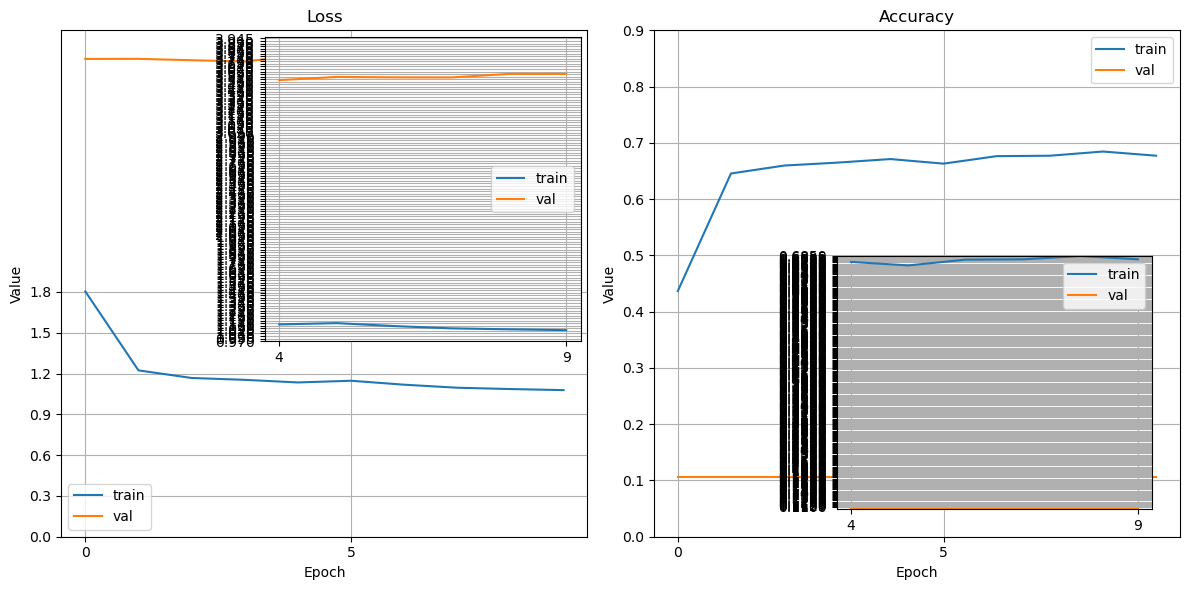

In [14]:
from utils import plot_loss_and_acc
plot_loss_and_acc(train_losses, val_losses, train_accuracies, val_accuracies, offset=4)

(9, 784, 10)


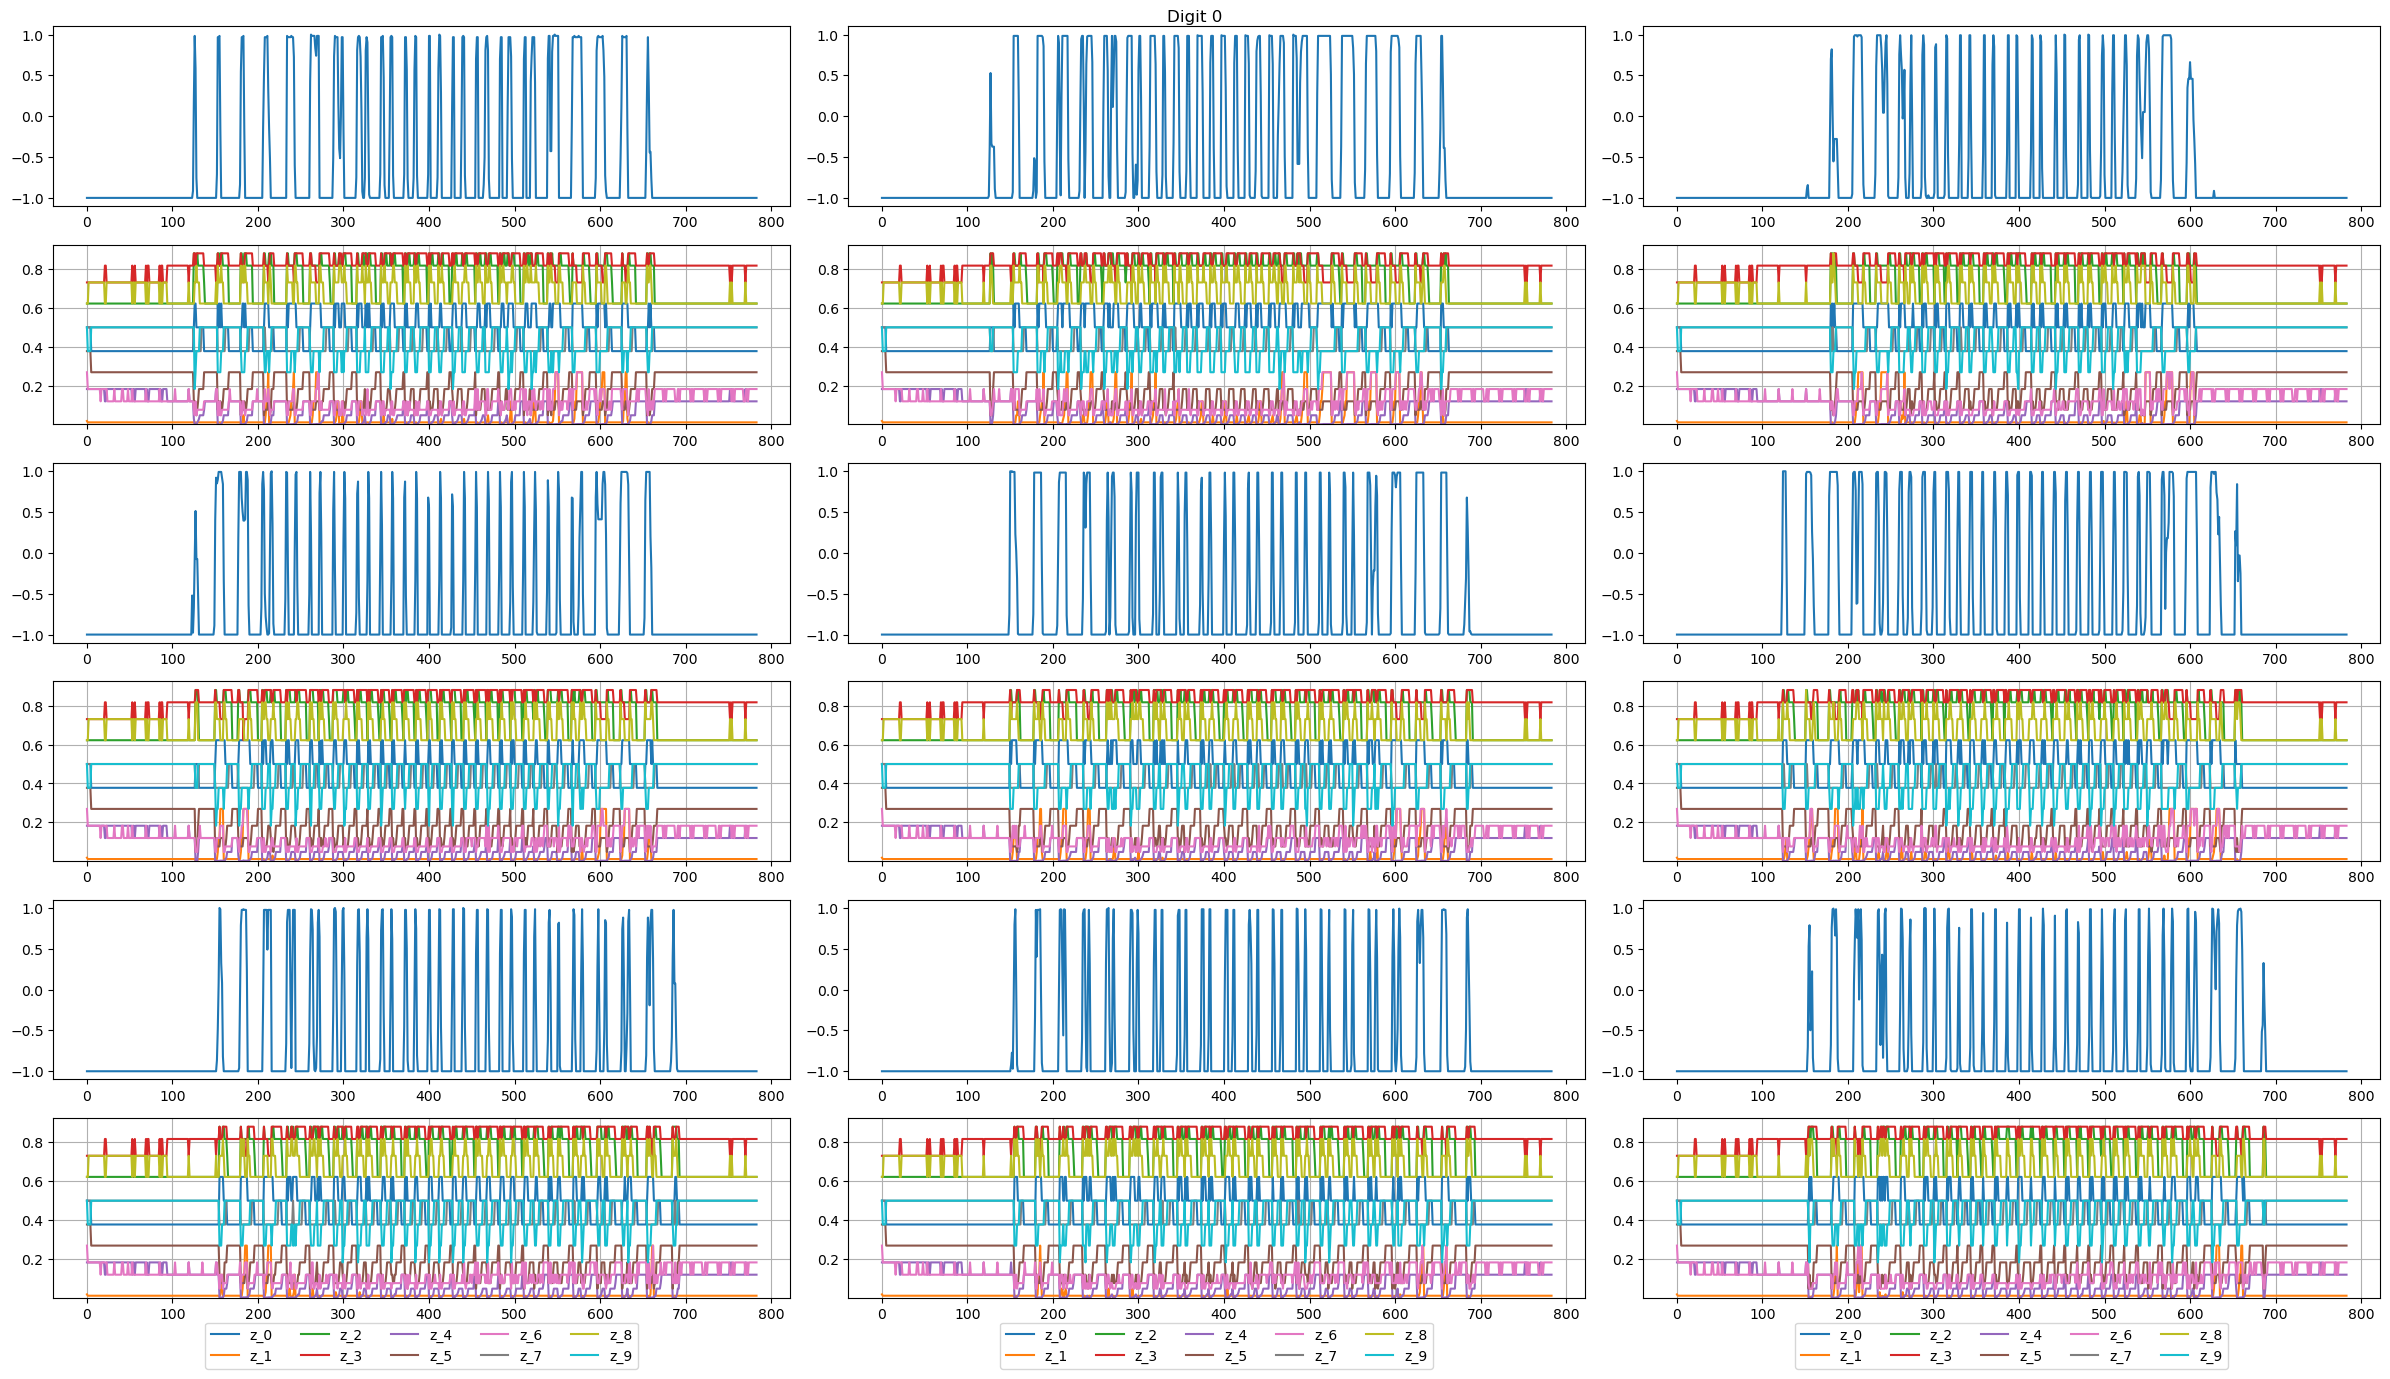

In [15]:
from utils import plot_digits
plot_digits(0, model, final_state.params, 'mingru_heinsen', 
            batch_x, batch_y, PLT_DIR, variable_to_plot='z',
            layer_to_plot=1, nb_components_to_plot=10)

(10, 784, 10)


/home/christian/LearningJAX/Flax/utils.py:571: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[-1, i].legend(ncol=legend_ncol, loc='upper center', bbox_to_anchor=(0.5, -0.1))


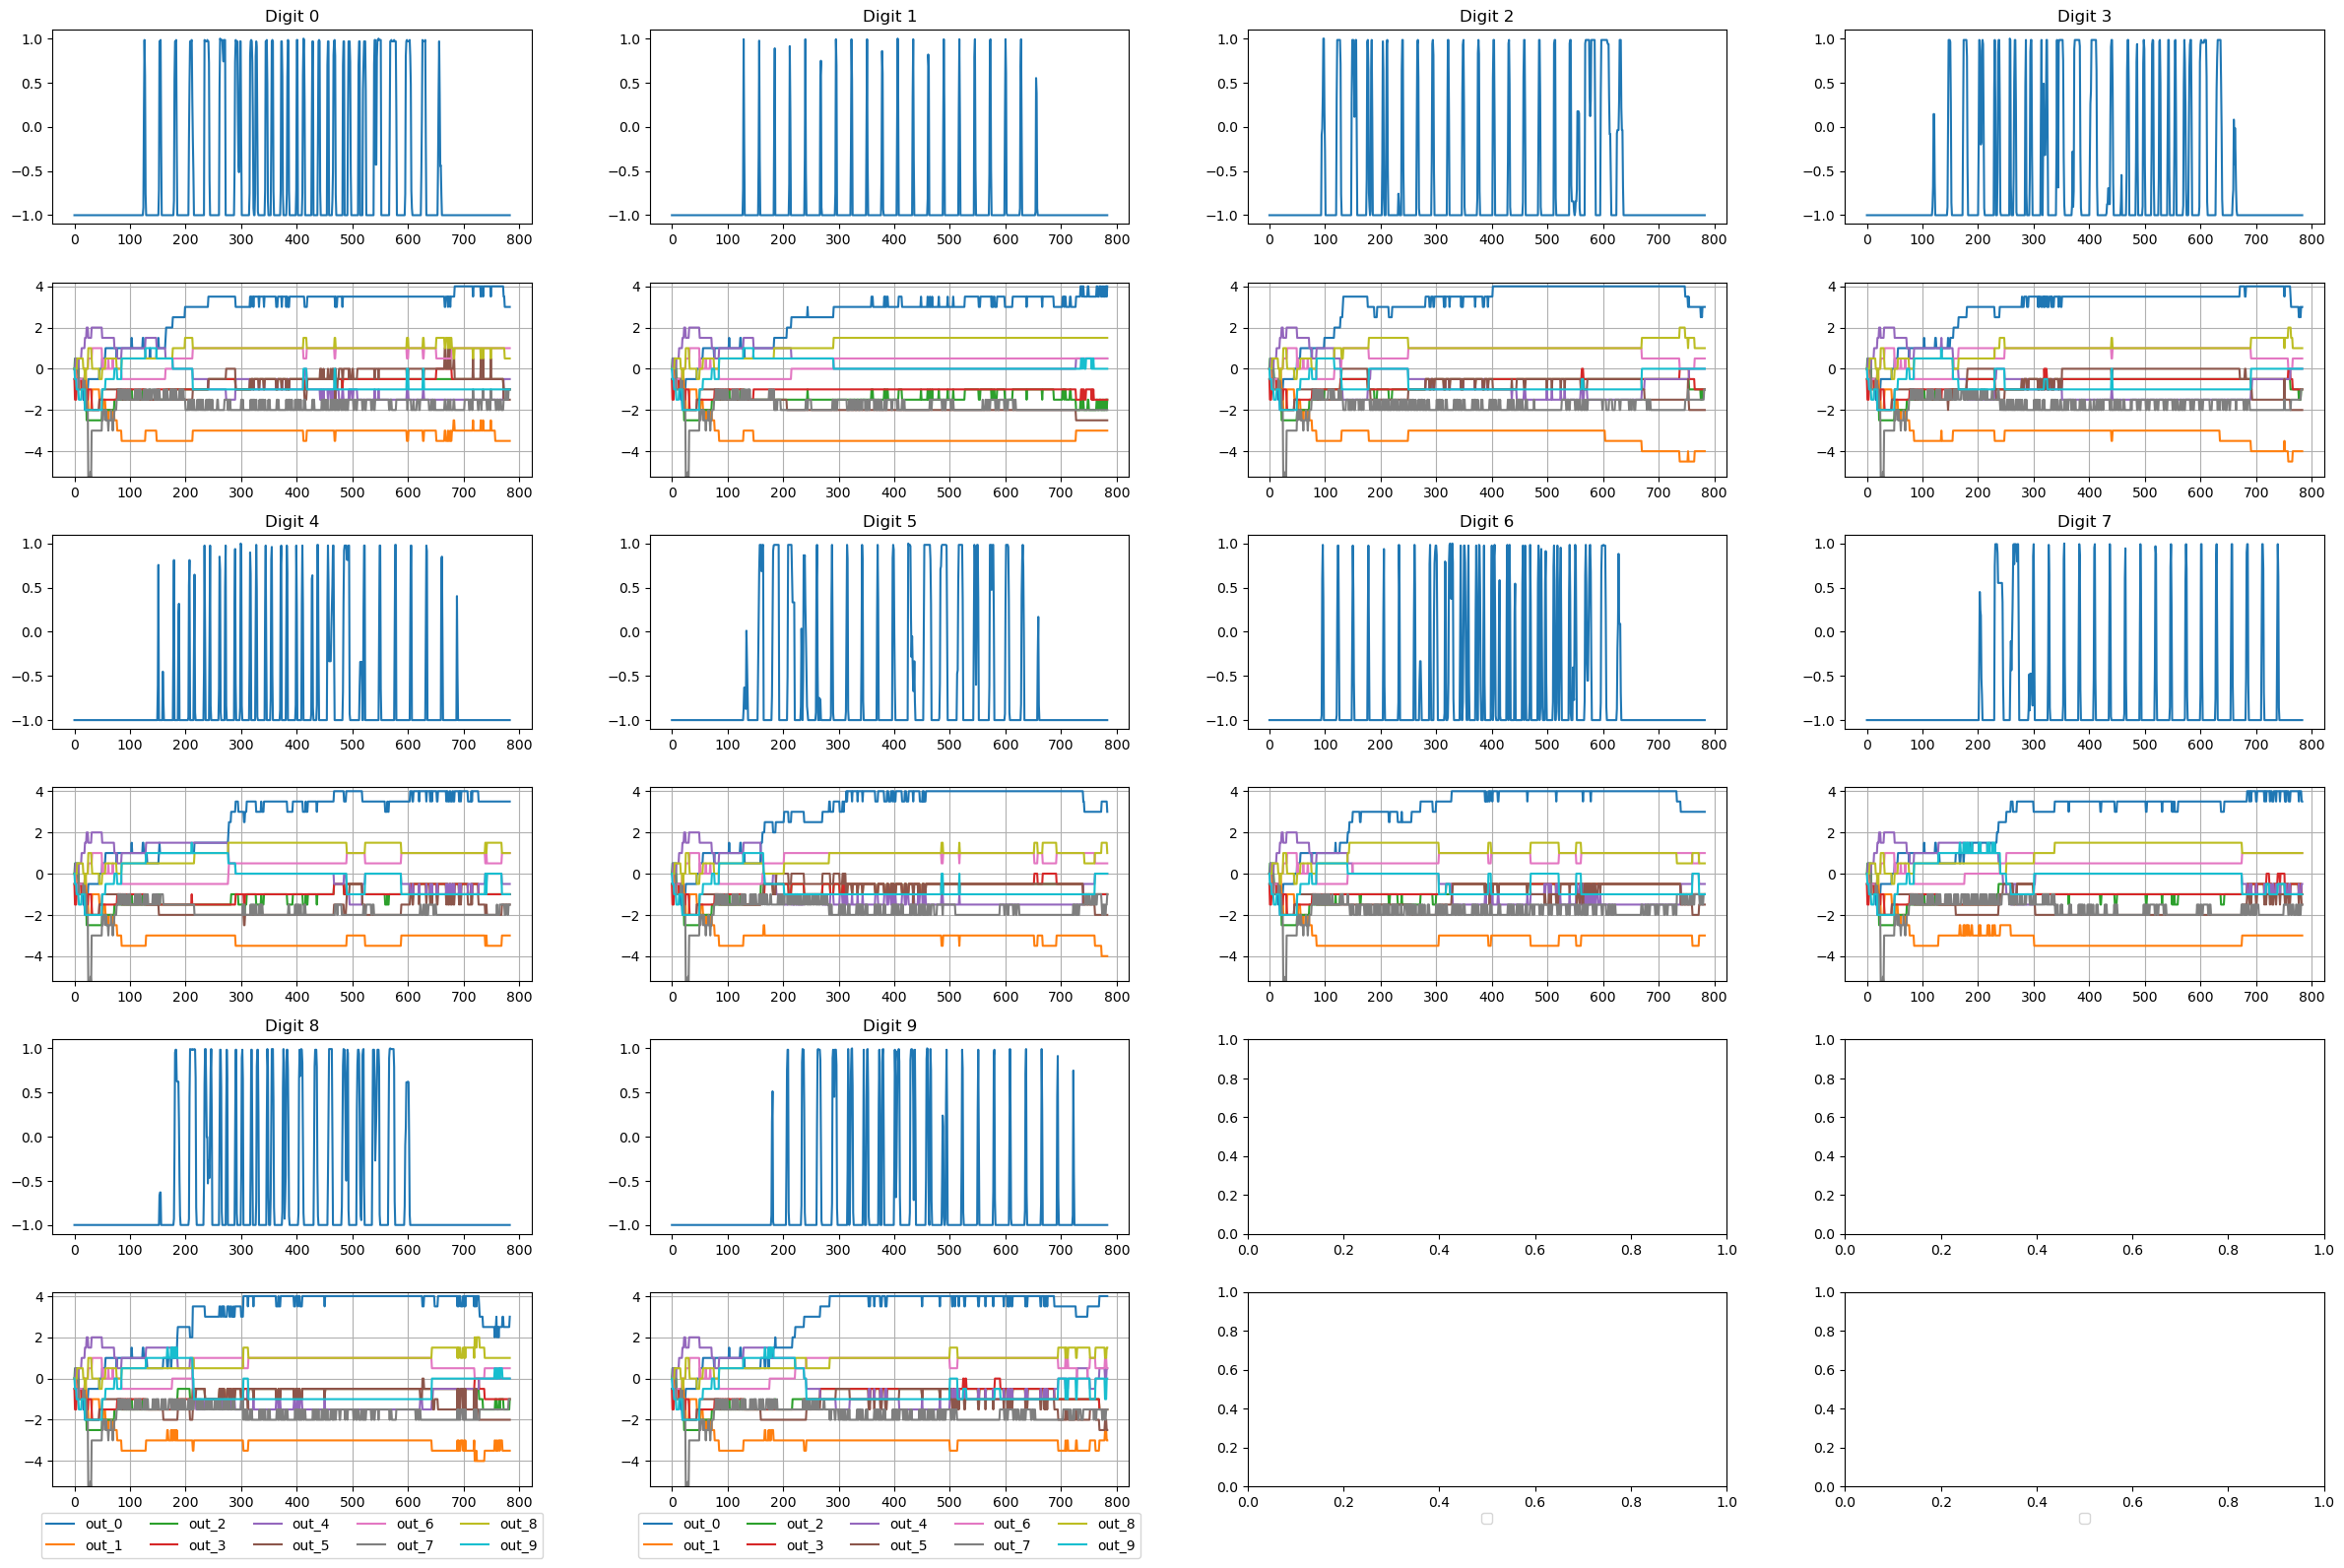

In [16]:
from utils import plot_all_digits
plot_all_digits(model, final_state.params, 'mingru_heinsen', batch_x, batch_y, plt_dir=PLT_DIR, 
                nb_components_to_plot=10, layer_to_plot=1, variable_to_plot='o')


4
4
(5, 784, 50)


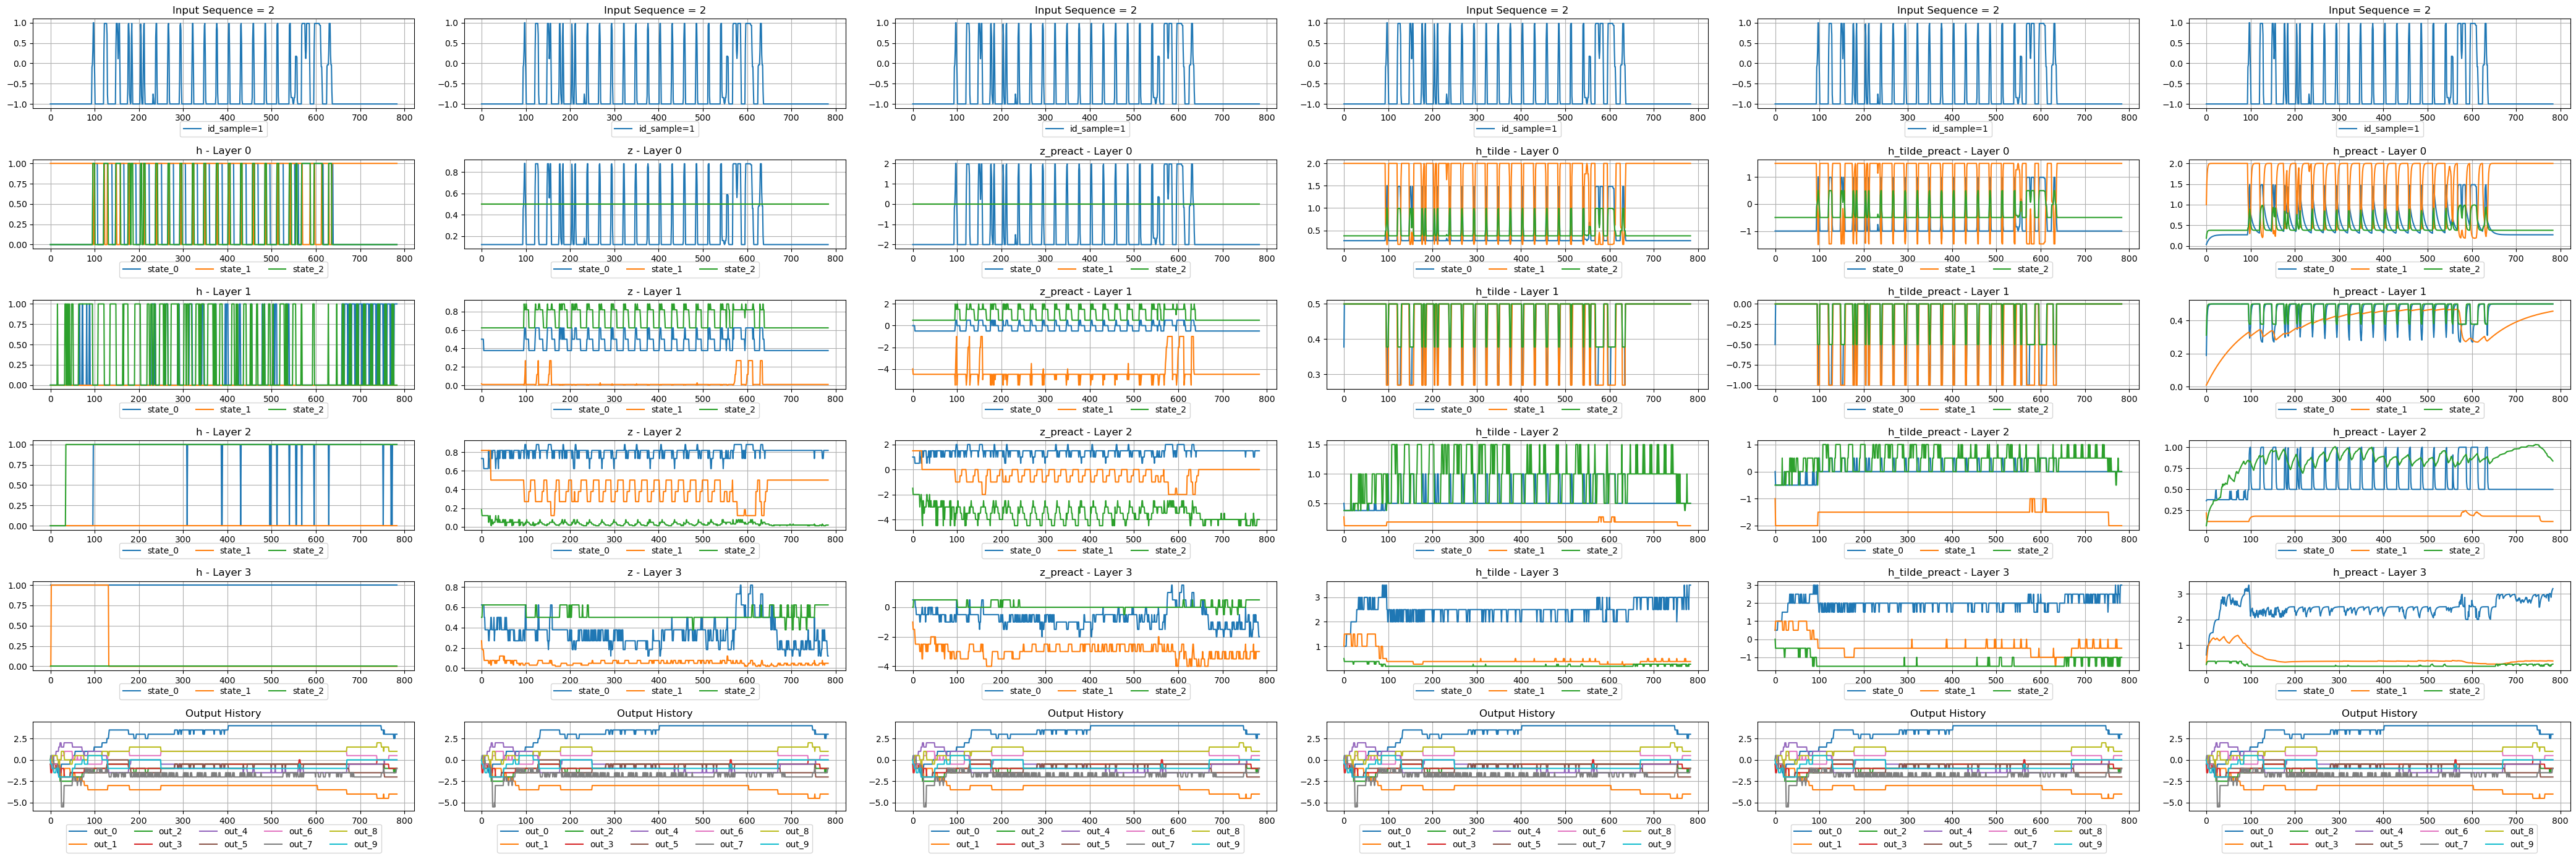

In [17]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=1, model_type='mingru_heinsen', variable_to_plot='all', nb_components_to_plot=3, zoom=False)

4
4
(5, 784, 50)


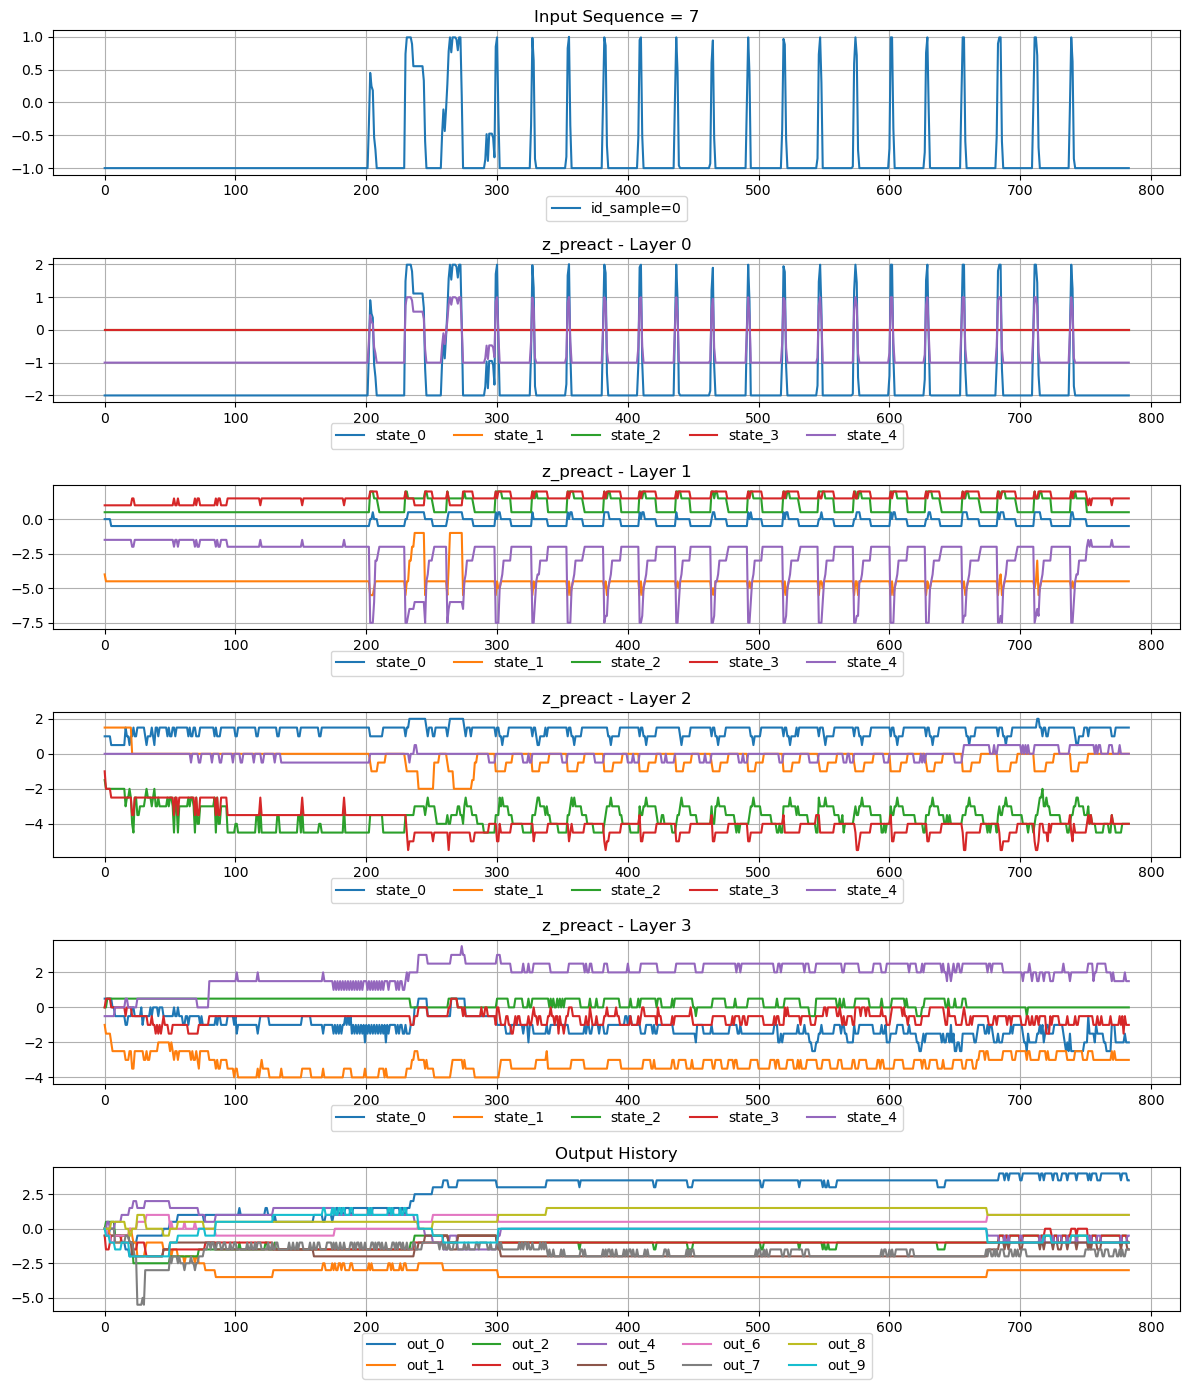

In [18]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z_preact')

4
4
(5, 784, 50)


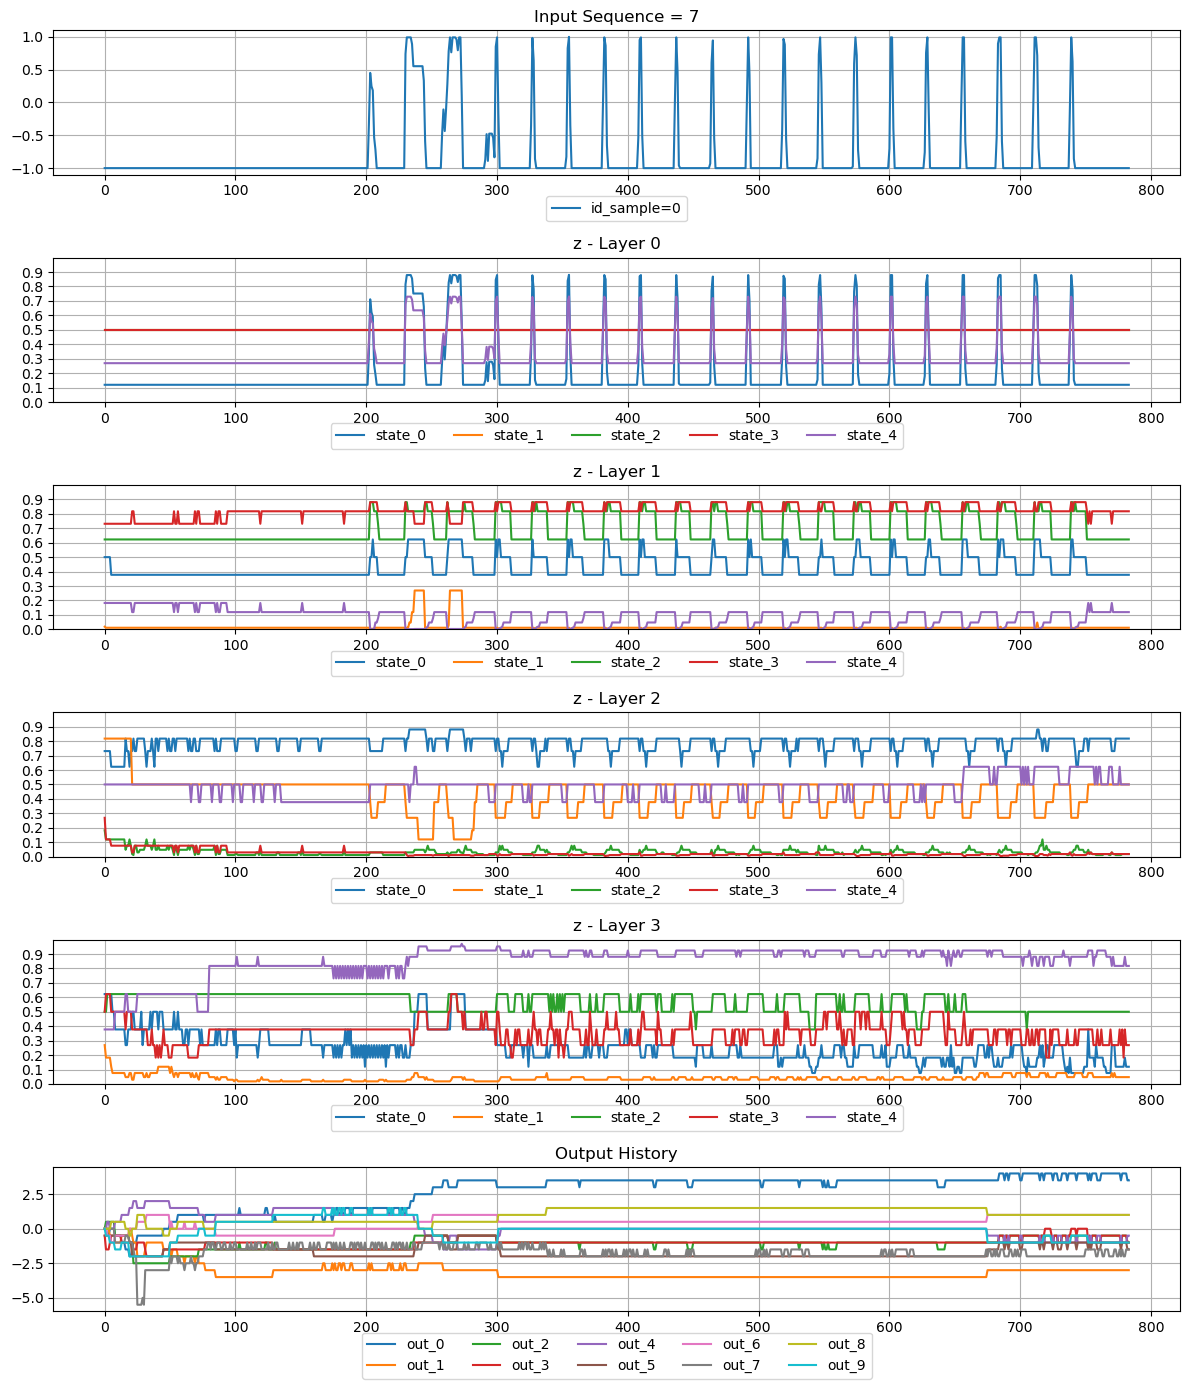

In [19]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')

4
4
(5, 784, 50)


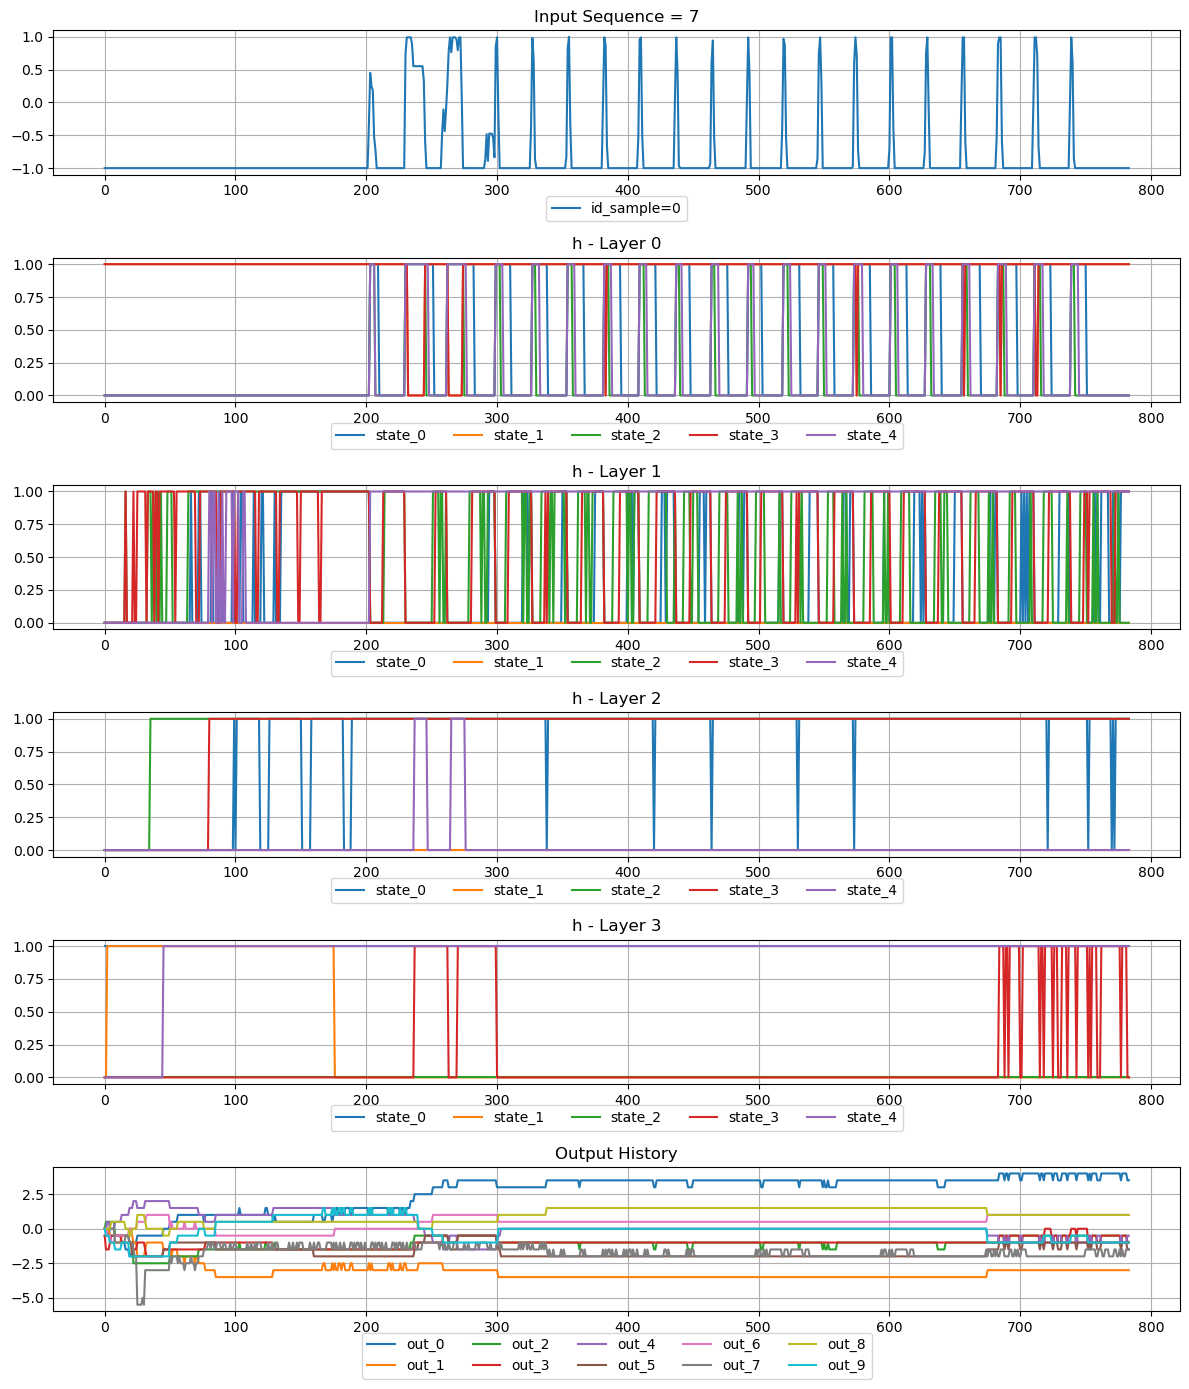

In [20]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='h')


4
4
(5, 784, 50)


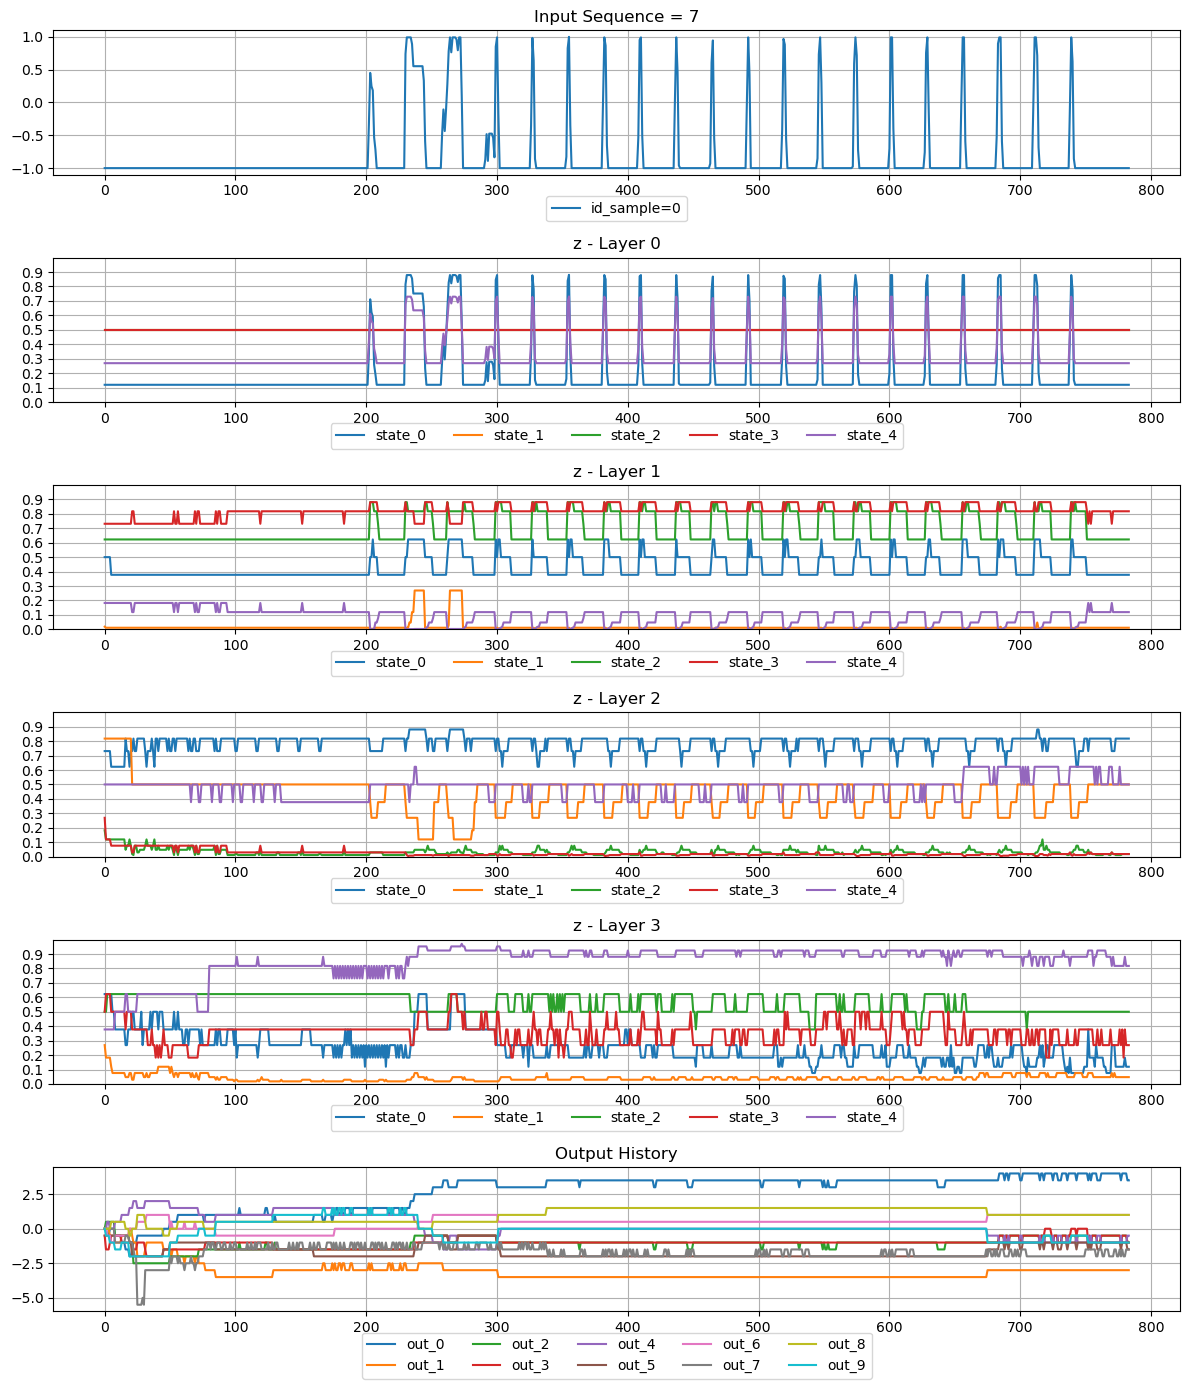

4
4
(5, 784, 50)


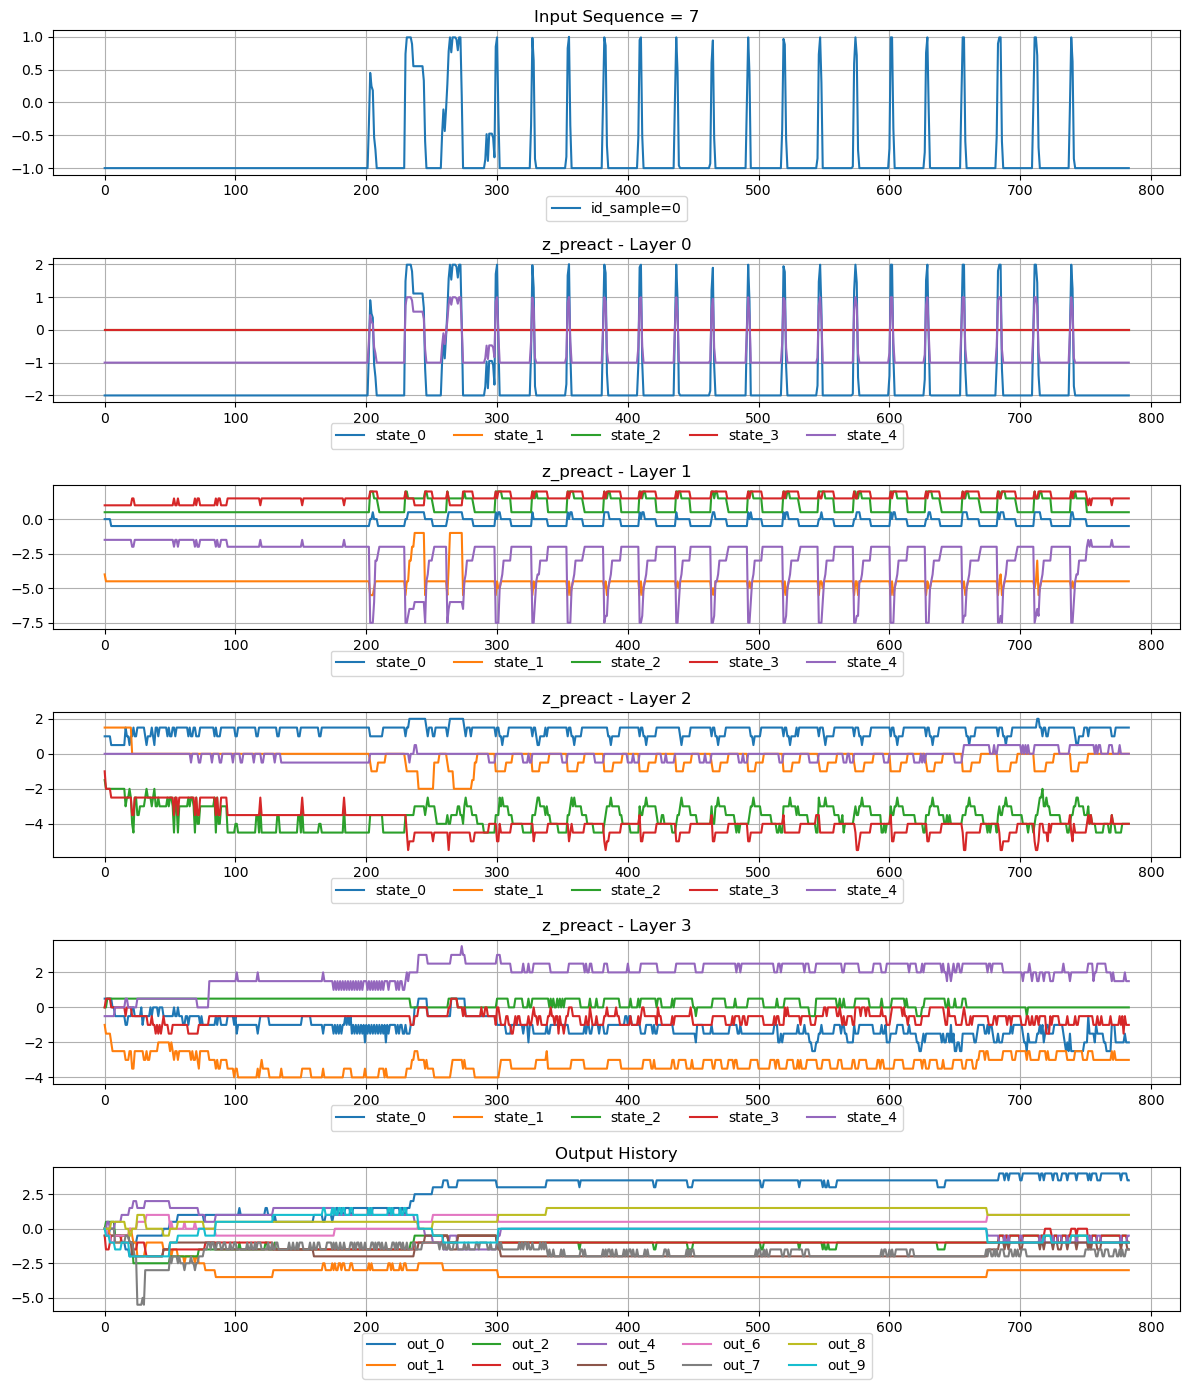

In [21]:
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')
plot_dynamics(model, final_state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=0, model_type='mingru_heinsen', variable_to_plot='z_preact')

In [22]:
def plot_distributions(var, name, compartment_labels=None, per_compartment=False, per_layer=False, layer_id=None):
    """
    Plot the distribution of z_preact and h_preact values per compartment.

    Args:
        z_preact: Array of z_preact values (e.g., shape [n_samples, n_compartments]).
        h_preact: Array of h_preact values (e.g., shape [n_samples, n_compartments]).
        compartment_labels: List of labels for compartments (optional).
    """
    n_compartments = var.shape[1]
    if compartment_labels is None:
        compartment_labels = [f"compartment {i}" for i in range(n_compartments)]

    # Plot z_preact distributions
    # plt.figure(figsize=(15, 5))
    if per_compartment:
        for i in range(n_compartments):
            sns.histplot(var[:, i], label=compartment_labels[i], fill=True, alpha=0.5, binwidth=0.02, stat="probability")#, bins=30)
            plt.title(f"Distribution of {name} values per compartment")

    else:
        sns.histplot(var.flatten(), label=f"layer {layer_id}", fill=True, alpha=0.5, binwidth=0.02, stat="probability")#,binrange = (-2.5,+2.5))
        plt.title(f"Distribution of {name} values per layer")

    plt.xlabel(name)
    plt.ylabel("probability")
    plt.legend()

In [23]:
params=final_state.params
if 'params' not in final_state.params:
    params = {'params': params}

state_hist, out_hist = model.apply(params, batch_x[:3])
components = 50




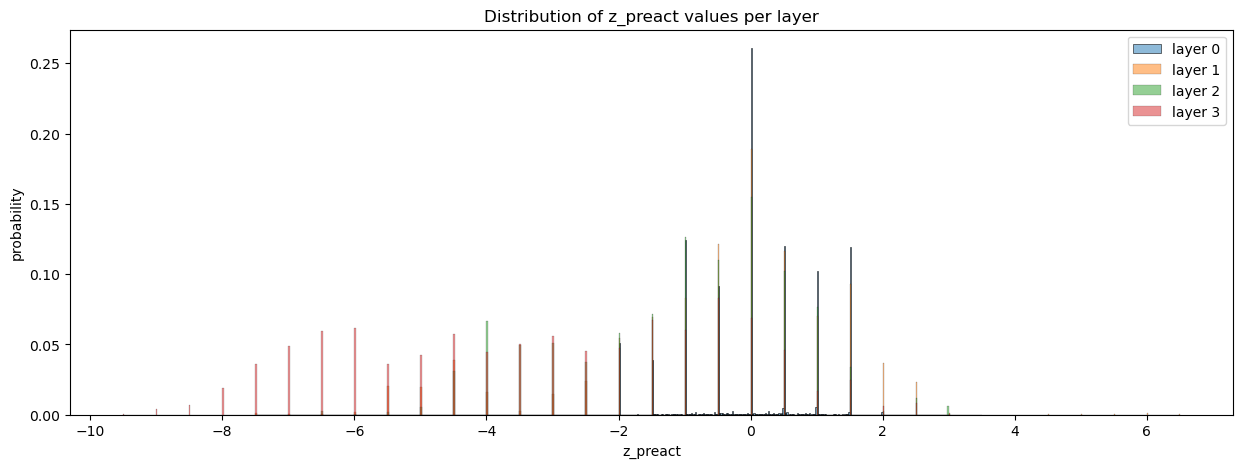

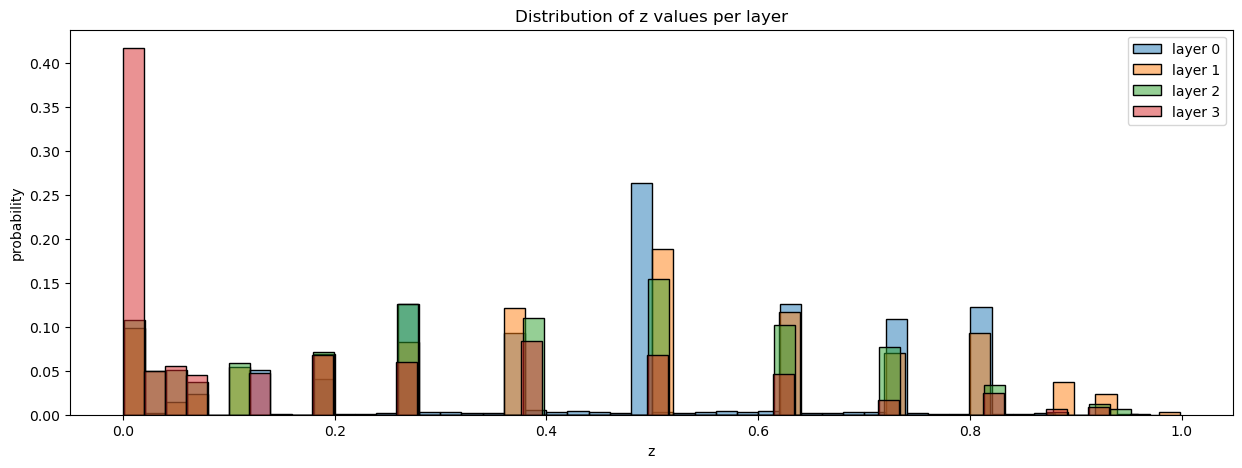

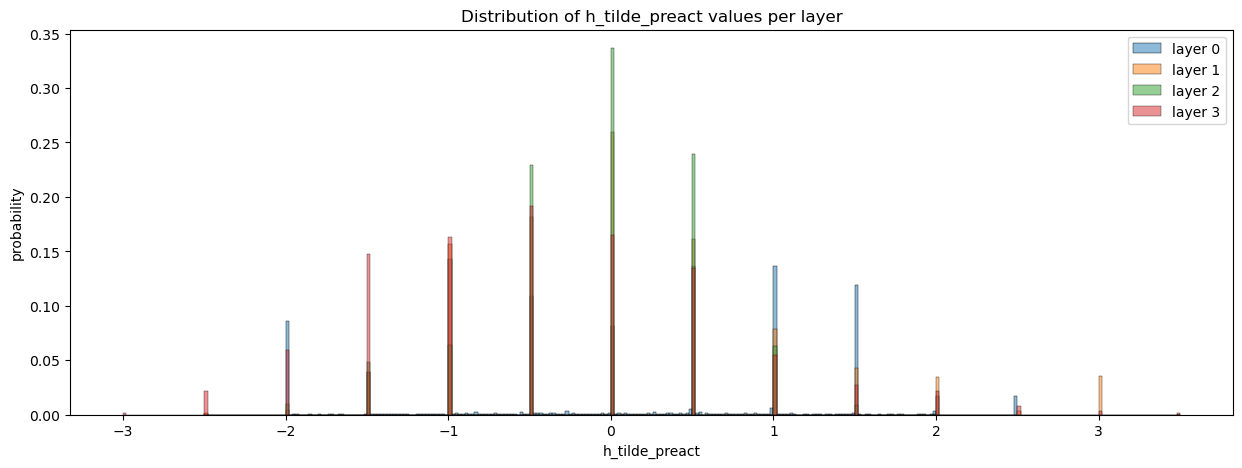

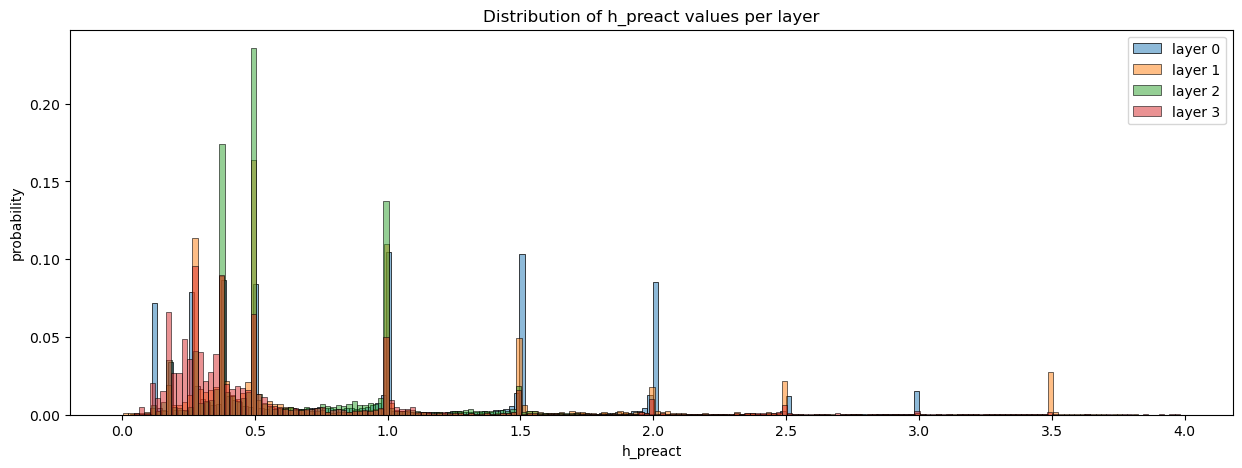

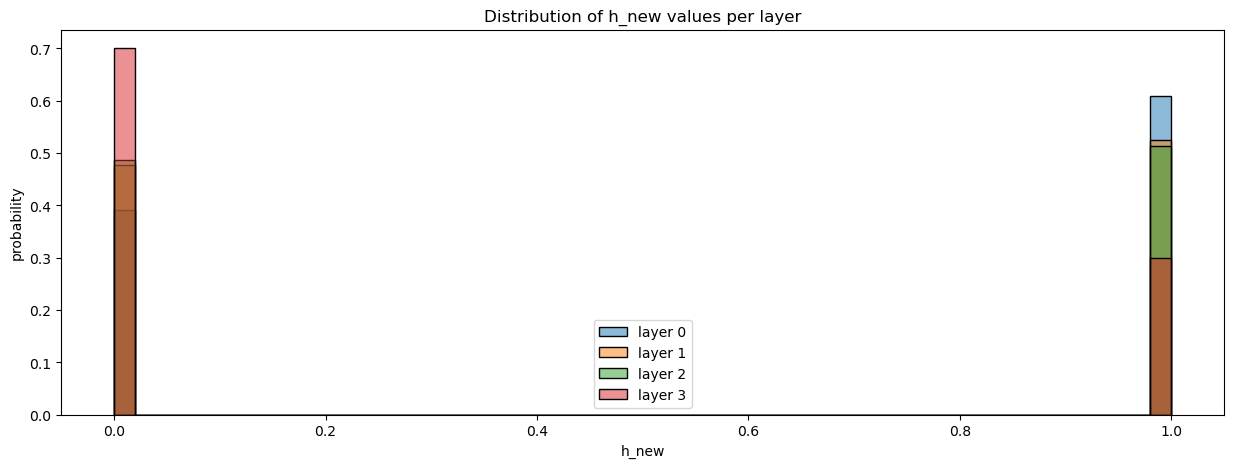

In [24]:
plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][1][0, :, :components], "z_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(jax.nn.sigmoid(state_hist[i][1][0, :, :components]), "z", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][2][0, :, :components], "h_tilde_preact", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][3][0, :, :components], "h_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][0][0, :, :components], "h_new", compartment_labels=None, layer_id=i)


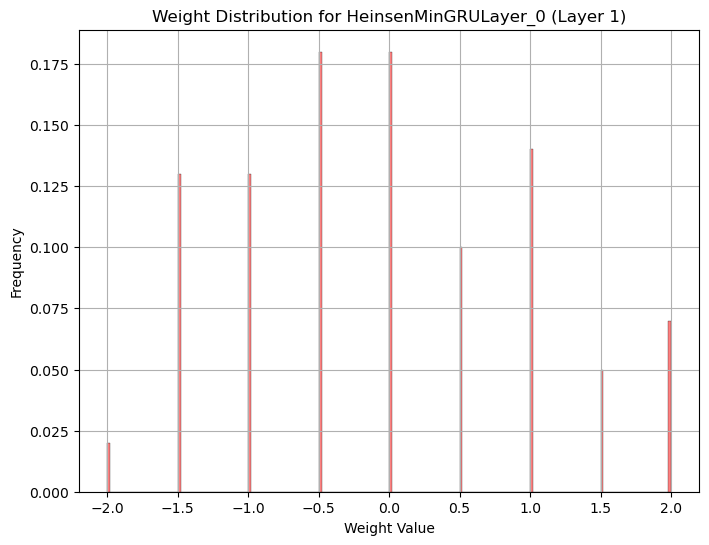

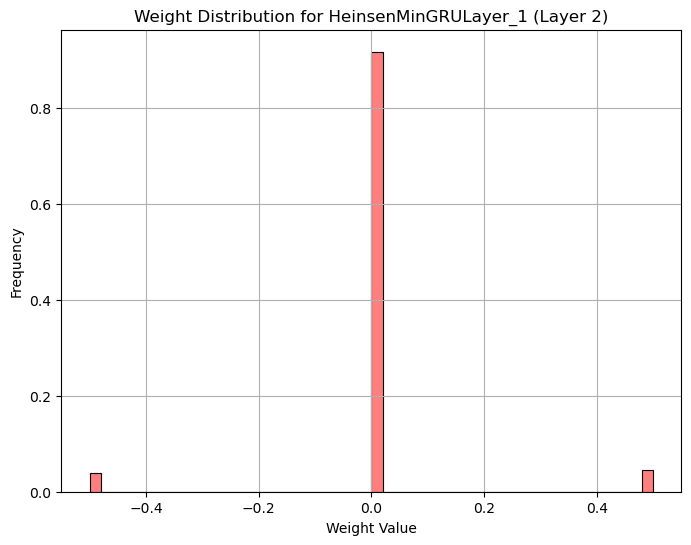

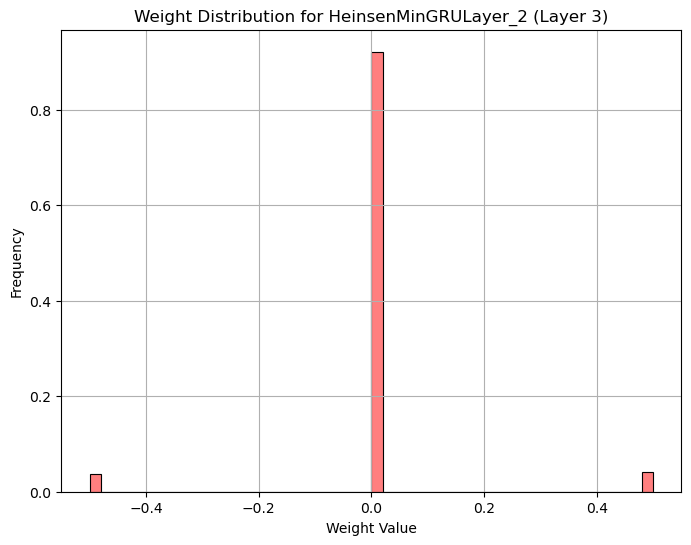

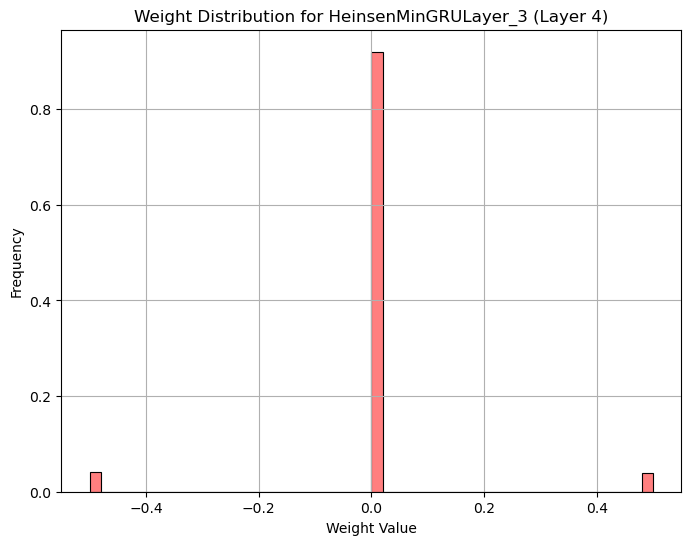

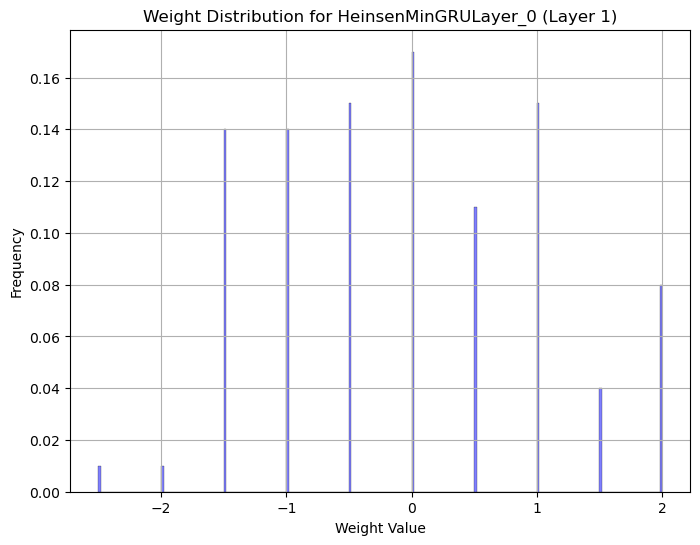

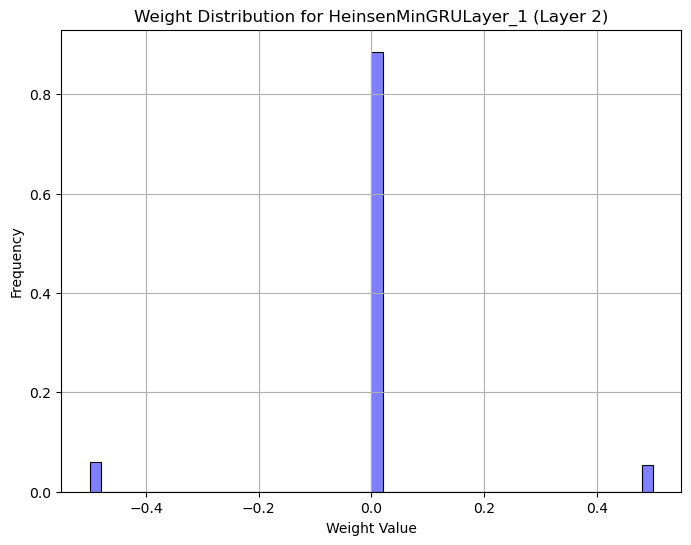

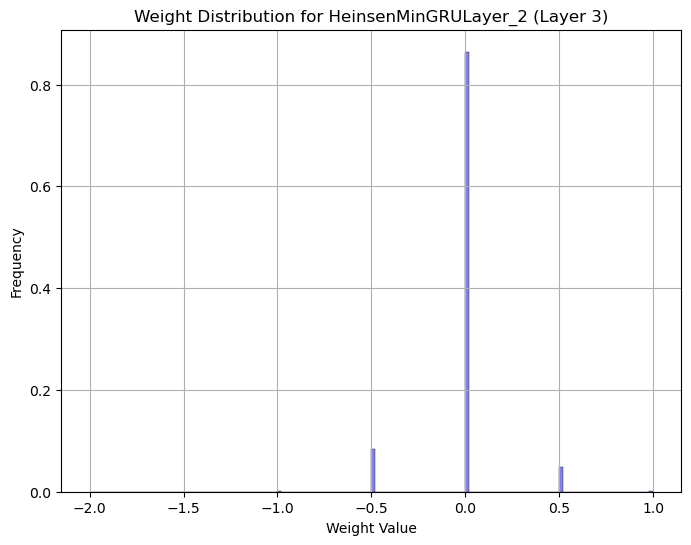

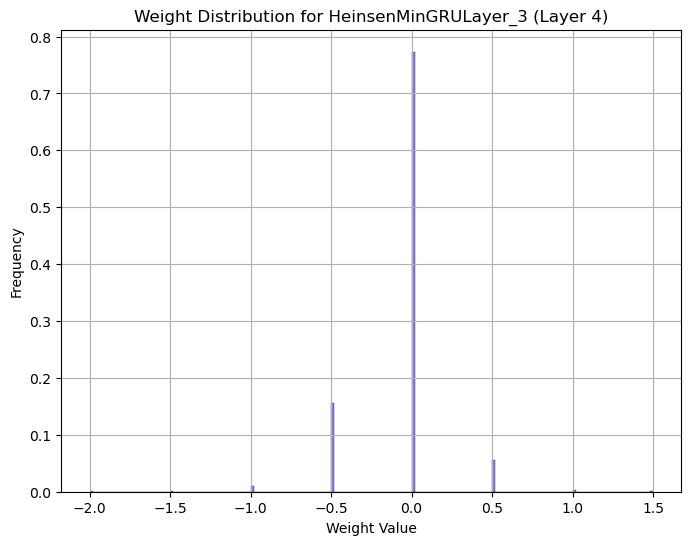

In [25]:
def plot_layer_weights_histogram(params, layer_prefix="HeinsenMinGRULayer", color=None):
    """
    Plot histograms of weights for each layer in the model.

    Args:
        params: Model parameters (e.g., from `final_state.params`).
        layer_prefix: Prefix for layer names in the parameter dictionary.
    """
    for layer_id, layer_name in enumerate(params.keys()):
        if layer_prefix in layer_name:
            # Extract weights for the layer
            layer_weights = params[layer_name]['Dense_x']['kernel']  # Adjust key names if needed
            layer_weights = np.array(layer_weights)  # Convert to NumPy array if necessary

            # Plot histogram
            plt.figure(figsize=(8, 6))
            sns.histplot(layer_weights.flatten(), fill=True, alpha=0.5, binwidth=0.02, stat="probability", color=color)
            plt.title(f"Weight Distribution for {layer_name} (Layer {layer_id})")
            plt.xlabel("Weight Value")
            plt.ylabel("Frequency")
            plt.grid(True)
            plt.show()

plot_layer_weights_histogram(round_weights_to_nearest(params_init["params"]), color="red")
plot_layer_weights_histogram(final_state.params, color="blue")

In [26]:
def plot_weight_time_constant_correlation(params, layer_id, color=None):
    """
    Plot the correlation between weight magnitude into a specific unit of a specific layer
    and the associated time constants.

    Args:
        params: Model parameters (e.g., from `final_state.params`).
        layer_id: The layer index to analyze.
        unit_id: The unit index within the layer to analyze.
        time_constants: Array of time constants for the specific layer.
    """
    # Extract weights for the specific layer
    layer_weights = params[f"HeinsenMinGRULayer_{layer_id}"]['Dense_x']['kernel'][:,:50]  # Adjust key names as needed
    # layer_bias = params['params'][f"HeinsenMinGRULayer_{layer_id}"]['Dense_x']['bias']  # Adjust key names as needed
    print(np.shape(layer_weights))
    weight_magnitudes = np.linalg.norm(layer_weights, axis=0)  # Compute L2 norms of weights into each unit
    print("Weight magnitudes:", np.shape(weight_magnitudes))

    key = jax.random.PRNGKey(args.seed)
    key_list = [key]*args.n_layers
    key_list = jax.random.split(key,args.n_layers)
    time_constants = jax.random.uniform(key_list[layer_id], (args.hidden_dim,), minval=args.time_decay_mean[1], maxval=args.time_decay_mean[0])

    # Plot correlation
    sns.jointplot(
        x=weight_magnitudes,
        y=time_constants,
        kind="scatter",
        marginal_kws=dict(bins=100, fill=True),
        color=color
    ).set_axis_labels("Weight Magnitude", "Time Constant")

    plt.suptitle(f"Weight Magnitudes and Time Constants (Layer {layer_id})", y=1.02)
    plt.show()

# look only at first 50

(1, 50)
Weight magnitudes: (50,)


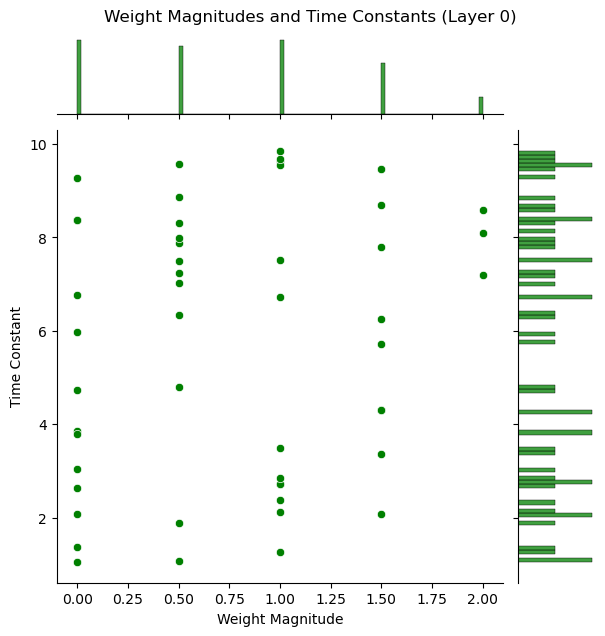

(50, 50)
Weight magnitudes: (50,)


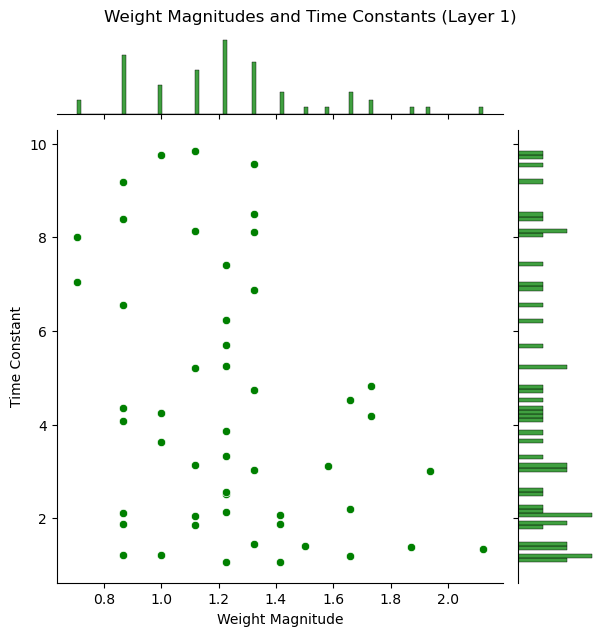

(50, 50)
Weight magnitudes: (50,)


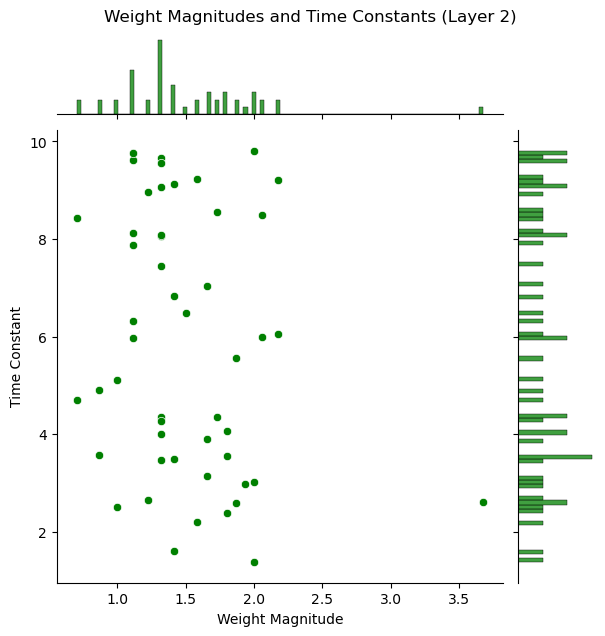

(50, 50)
Weight magnitudes: (50,)


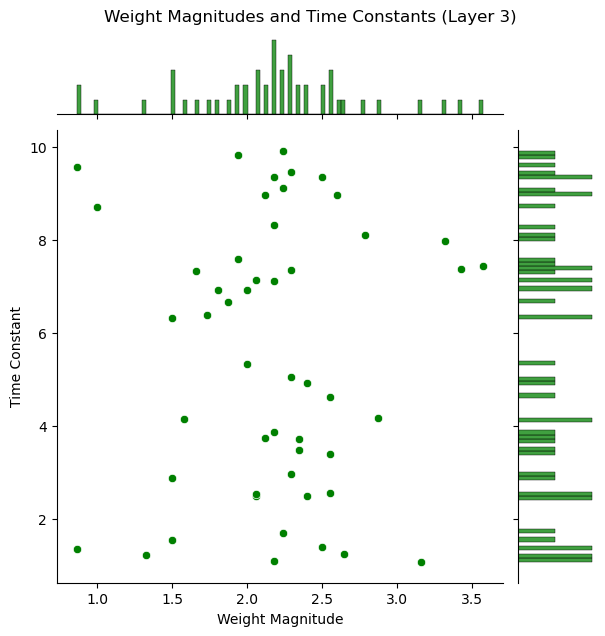

(1, 50)
Weight magnitudes: (50,)


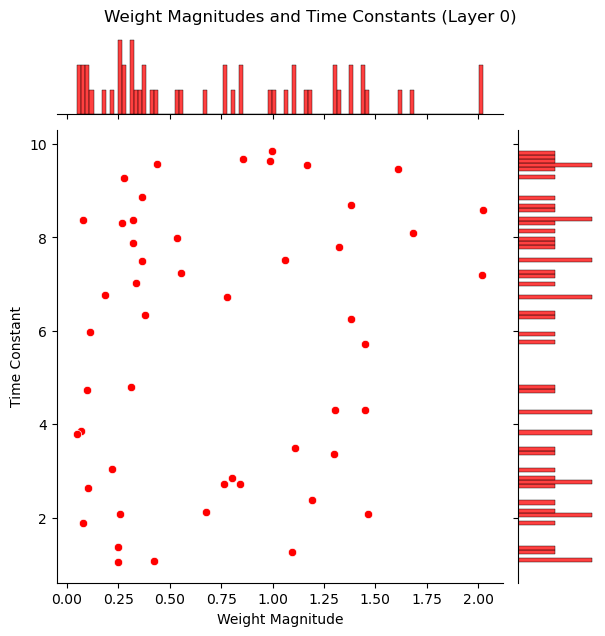

(50, 50)
Weight magnitudes: (50,)


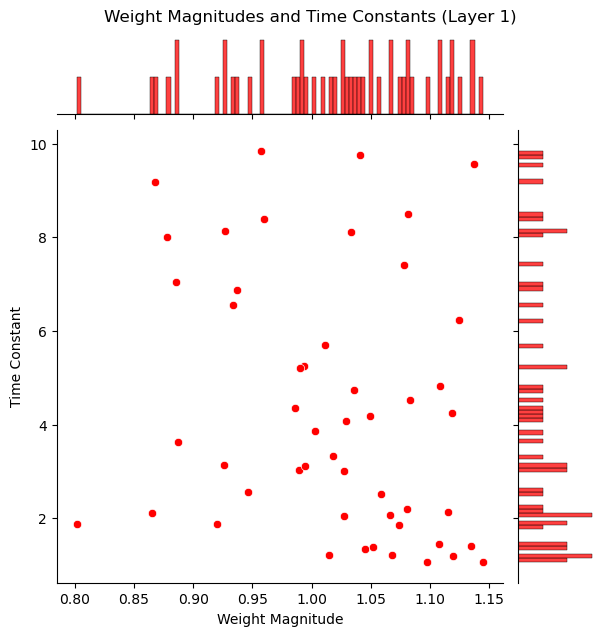

(50, 50)
Weight magnitudes: (50,)


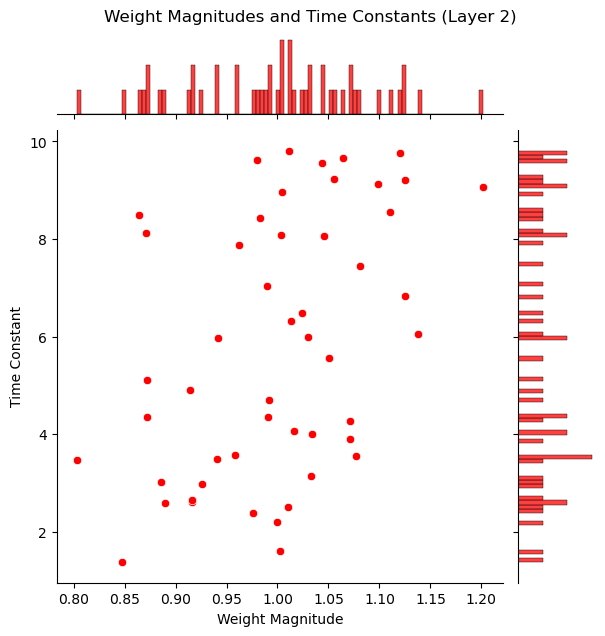

(50, 50)
Weight magnitudes: (50,)


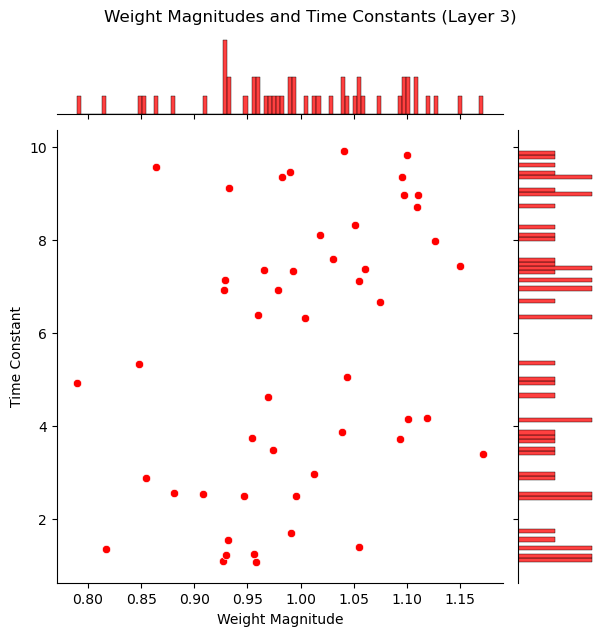

In [27]:
layer_id = 2  # Specify the layer index
# print(final_state.params)
for i in range(args.n_layers):
    plot_weight_time_constant_correlation(final_state.params, i, color="green")



for i in range(args.n_layers):
    plot_weight_time_constant_correlation(params_init["params"], i, color="red")

In [28]:
final_state = checkpoints.restore_checkpoint("LearningJAX/Flax/checkpoints/mingru_heinsen/mnist/sequential_h50_l4_dyn_alllayer_dyn_lr0.001_act_threshold10.0testing", target=final_state)

params=final_state.params
if 'params' not in final_state.params:
    params = {'params': params}

state_hist, out_hist = model.apply(params, batch_x[:3])
components = 50
layer_id = 1



h_new = state_hist[layer_id][0][0, :, :components]
z_preact = state_hist[layer_id][1][0, :, :components]
h_tilde_preact = state_hist[layer_id][2][0, :, :components]
h_preact = state_hist[layer_id][3][0, :, :components]



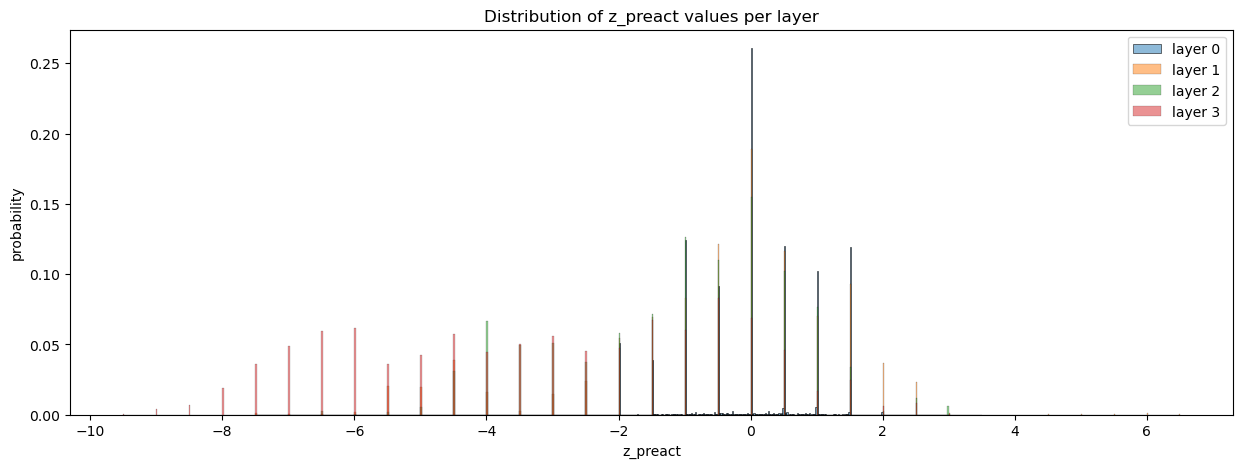

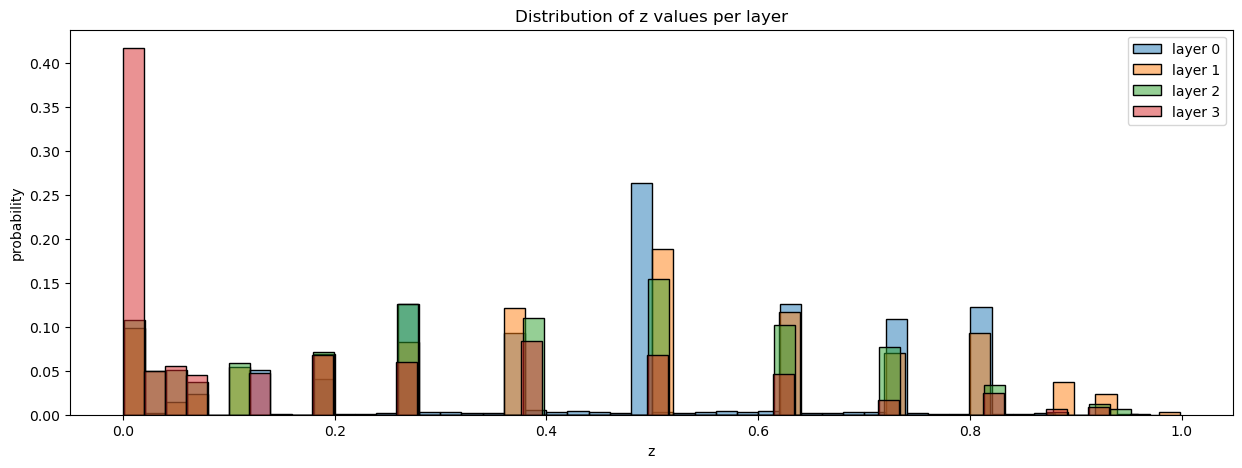

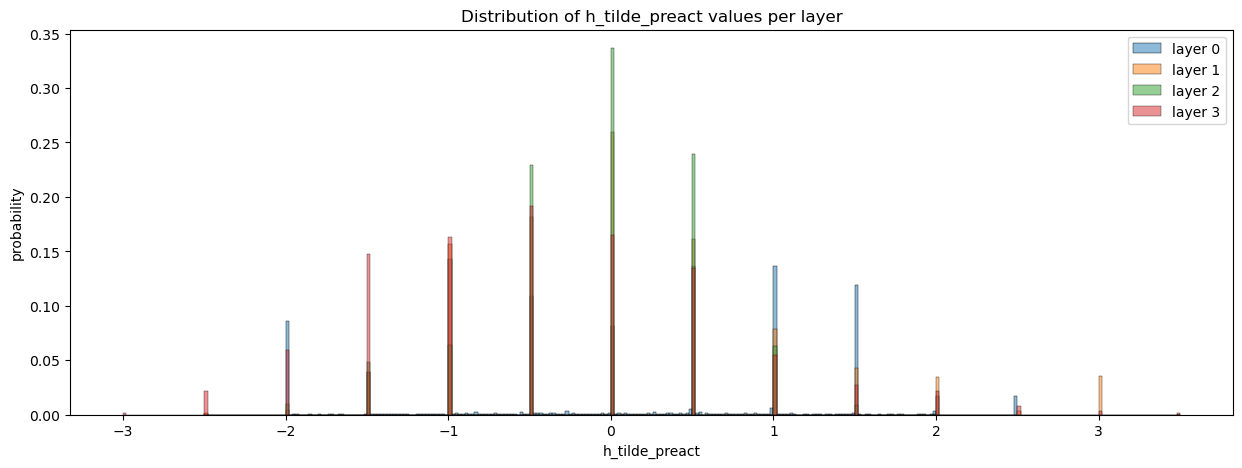

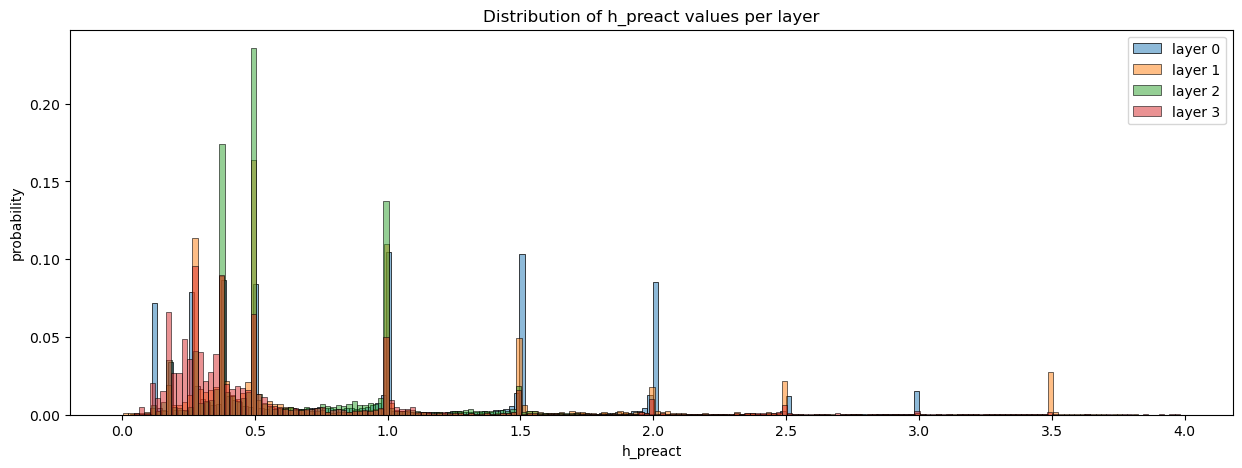

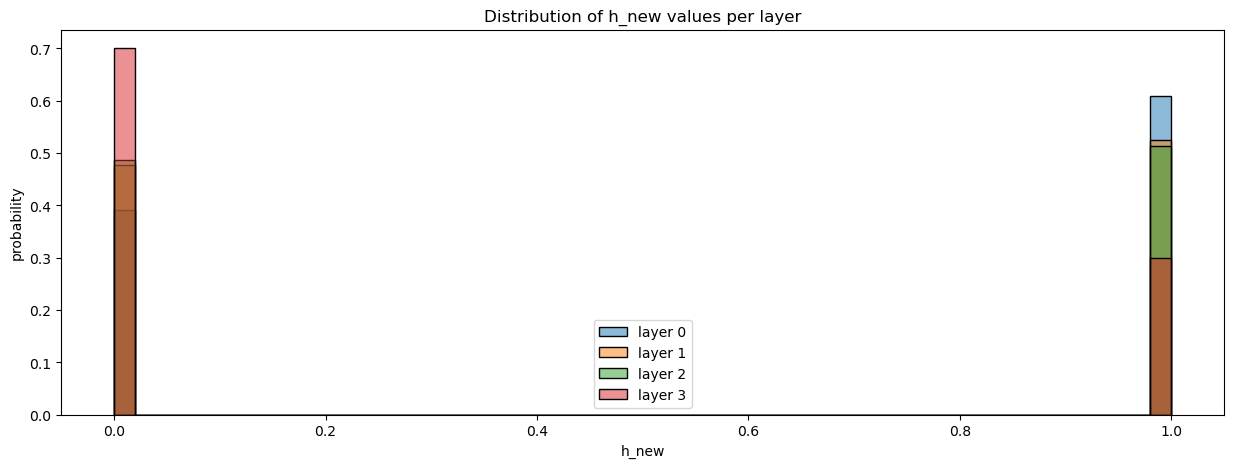

In [29]:
plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][1][0, :, :components], "z_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(jax.nn.sigmoid(state_hist[i][1][0, :, :components]), "z", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][2][0, :, :components], "h_tilde_preact", compartment_labels=None, layer_id=i)


plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][3][0, :, :components], "h_preact", compartment_labels=None, layer_id=i)

plt.figure(figsize=(15, 5))
for i in range(args.n_layers):
    plot_distributions(state_hist[i][0][0, :, :components], "h_new", compartment_labels=None, layer_id=i)
